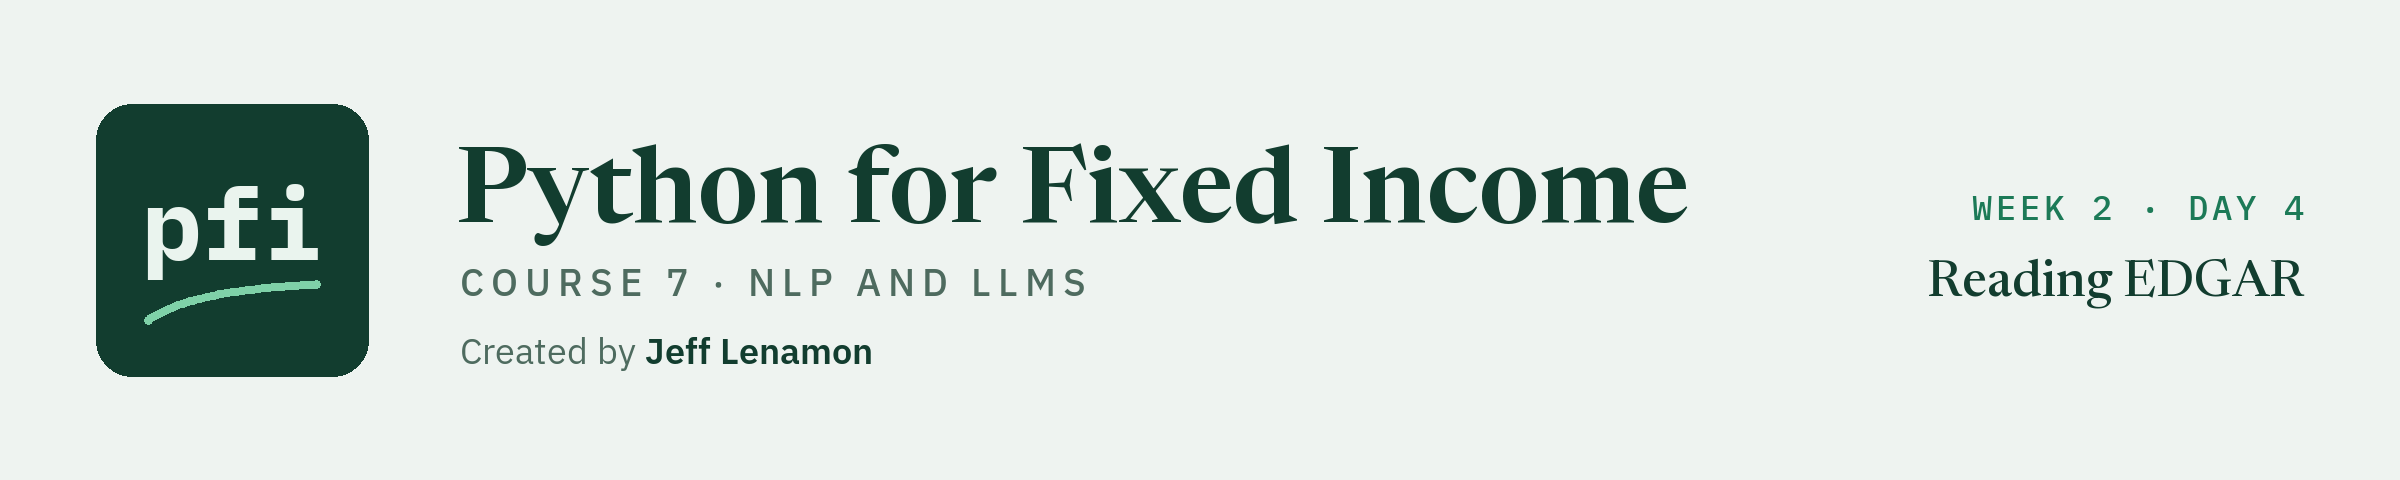

# Reading EDGAR

Week 2, Day 4. Today you read filings the way EDGAR serves them: the addresses, the SEC's rules for automated requests, a fetch function tested without the network, HTML turned into text, and a 10-K cut into its items.

**Data:** `course7_boyd_10k_2025.htm`: Boyd Gaming Corporation, Form 10-K for the fiscal year ended December 31, 2025, filed 2026-02-20, accession 0001437749-26-004908: **real**, a public record on sec.gov, quoted for descriptive extraction only.

**Data:** `course7_indentures/boyd_2021.txt`: Boyd Gaming Corporation, Indenture dated as of June 8, 2021, 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495: **real**, a public record on sec.gov, quoted for descriptive extraction only.

**Data:** `course7_8k_items.csv`, 5,126 item sections of Form 8-K current reports filed on EDGAR, 2019 to 2025, each labelled by the item its filer chose: **real**, public records (sec.gov), a sample drawn by the course (DATA.md).

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course7_nlp_and_llms/week2/day4/09_reading_edgar.ipynb)

**EDGAR** is the SEC's system for filings: every 10-K, 8-K, and exhibit the course has read so far came from it. Days 1 to 8 read the course's copies in `data/`, made once by the course's tools. Today you see how those copies were made: where a filing lives on sec.gov, what the SEC asks of a program that reads it, how the HTML becomes the text every earlier day used, and how a 10-K is cut into its items.

**This notebook never sends a request to EDGAR when it runs.** `FETCH_LIVE = False` is set in section 9.2, so every request cell shows the code you would run, prints the address it would request, and reads the course's committed copy of the same document instead. Bring It Home runs one real request from PowerShell, with your own name and email in the User-Agent; every example here uses `Student Name` and `student@example.com`.

**The rules for real documents, as on every day of this course.**

* **The documents are real.** The 10-K, the indenture, and the 8-K sections are public records on sec.gov, written by their filers and quoted exactly as filed, with a source line under every excerpt.
* **Described, never judged.** Today's numbers are sizes, positions, and word counts of documents. No sentence reads a filing for a view on its company or its securities.
* **Issuer names appear only as the authors of the documents being read**: in the data lines, the addresses, and the source lines.

**Rows.** No model is fitted or scored in this notebook: every number describes one 10-K, one indenture, and two sections of one 8-K as filed.

Today you will:

1. Build EDGAR's addresses as strings: a company's submissions, a filing's folder, a document, a full-text search.
2. Read the SEC's rules for automated requests on its own pages.
3. Write `sec_headers` and `edgar_get`, and test them with a fake session and a fake clock.
4. Turn the 10-K's HTML into text with `html_to_text`, and see what the inline XBRL header is.
5. Cut the 10-K into its items with `split_items`, past the table of contents and the cross-references.
6. Check that the indenture every earlier day read is exactly `html_to_text` of the filed exhibit.
7. Cut two sections of one 8-K at their headings, and see a cross-reference that must not cut.

Q. Set up today's work folder: the thread settings, the quiet-loading settings, the seed, and today's four data files.

In [1]:
# today's setup: thread settings, quiet model loading, the modules, the seed, the course data, a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, or PyTorch is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# the model libraries print download bars and notices; these lines must run before they are imported
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("torch", "torch"), ("transformers", "transformers"), ("sentence_transformers", "sentence-transformers"), ("openai", "openai"), ("pydantic", "pydantic"), ("bs4", "beautifulsoup4"), ("pypdf", "pypdf"), ("pypdfium2", "pypdfium2"), ("dotenv", "python-dotenv"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course7_nlp_and_llms/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "torch": "2.14.1", "transformers": "5.19.0", "sentence-transformers": "6.1.0", "openai": "3.26.0", "pydantic": "2.13.5", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name].split("+")[0] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "course7_fomc_statements.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course7_09_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["course7_boyd_10k_2025.htm", "course7_indentures/boyd_2021.htm", "course7_indentures/boyd_2021.txt", "course7_8k_items.csv"]
for name in DATA_FILES:
    (work / name).parent.mkdir(parents=True, exist_ok=True)
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, torch 2.14.1, transformers 5.19.0, sentence-transformers 6.1.0, openai 3.26.0, pydantic 2.13.5, pytest 9.1.1
Work folder: pfi_course7_09_8_3ujlog, in your temp folder
Data files from the data folder of the course repo: course7_boyd_10k_2025.htm, course7_indentures/boyd_2021.htm, course7_indentures/boyd_2021.txt, course7_8k_items.csv
SEED = 42


* The setup cell is day 1's, line for line (day 1 explains each line). Today runs no model, so the cell has no PyTorch line.
* Four files are copied into the work folder: the Boyd 10-K as filed (HTML with inline XBRL), the Boyd indenture as filed and its text, and the 8-K sections. The course's tools fetched them from sec.gov once, within the rules this notebook teaches; the notebook reads them from disk.

Q. Write the earlier courses' modules today needs, unchanged: `mlkit.py`.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `textkit.py` and `test_textkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile textkit.py
"""textkit: text as data for fixed income, from a regular expression to a checked LLM extraction.

Written day by day in Python for Fixed Income, Course 7: NLP and LLMs.

Conventions, the same in every function:
- Text is normalized by normalize_text before it is counted, searched, or compared: Unicode NFC, a fixed map of
  look-alike characters (no-break space, non-breaking hyphen, curly quotes, dashes), one space for every run of
  white space, and one newline between paragraphs. Source files keep the text exactly as published.
- A token is a run of lower-case letters and digits, joined by single hyphens, apostrophes, or full stops
  (TOKEN_PATTERN): "mortgage-backed" and "4.750" are one token each, "1/4" is two. No stemming.
- Section numbers and 8-K item codes are text ("4.12", "2.04"), so "4.10" never becomes 4.1.
- Money is in US dollars as whole numbers of dollars (855_000_000); percentages are as the source writes them
  (15.0 means 15.0 percent); ratios are floats with the unit "x" (2.0 means 2.00 to 1.00).
- The seed is 42 wherever a function takes one.
- Every output describes what a document says. Nothing here is a forecast, a rating, or a credit view.
- Empty inputs, or inputs of the wrong shape, raise ValueError with a message that says what was wrong.
"""
import re  # regular expressions
import unicodedata  # Unicode normalization

import pandas as pd  # tables with labels

import mlkit  # Course 4's module, unchanged: the split checks and the description check

# one token: letters and digits, joined by single hyphens, apostrophes, or full stops
TOKEN_PATTERN = r"[a-z0-9]+(?:[-'.][a-z0-9]+)*"
# a section heading at the start of a line: "Section 4.12. Limitation on Indebtedness" or "SECTION 4.12"; the
# title, if any, starts with a capital letter or "[", so a cross-reference that starts a line ("Section 4.12(b)",
# "Section 4.13 or Section 4.19 of the Indenture") is not a heading
SECTION_PATTERN = (r"^[ \t]*(?:SECTION|Section)[ \t]+(?P<number>\d{1,2}\.\d{1,2})(?![\d(])\.?"
                   r"(?:[ \t]+(?P<title>[A-Z\[][^\n]*?))?[ \t]*(?:\.(?=[ \t]|$)|$)")
# look-alike characters and the plain character each becomes (COURSE7_SPEC.md, "Conventions")
CHARACTER_MAP = {
    "\u00a0": " ",  # no-break space
    "\u2010": "-",  # hyphen
    "\u2011": "-",  # non-breaking hyphen
    "\u2013": "-",  # en dash
    "\u2014": "-",  # em dash
    "\u2018": "'",  # left single quote
    "\u2019": "'",  # right single quote
    "\u201c": '"',  # left double quote
    "\u201d": '"',  # right double quote
}


def normalize_text(text: str) -> str:
    """Return text with look-alike characters made plain and white space tidied.

    Input: text, any string.
    Output: the text after three steps: Unicode NFC; each character of CHARACTER_MAP replaced by its plain form;
    every run of white space that holds a line break becomes one newline (a paragraph break), and every other run
    of white space becomes one space; no space or newline at either end.
    Convention: idempotent, so normalize_text(normalize_text(t)) == normalize_text(t). Run it on both sides of any
    comparison of text.
    Raises ValueError if text is not a string.
    """
    if not isinstance(text, str):
        raise ValueError(f"text must be a string, not {type(text).__name__}")
    # one code point per accented letter, then the fixed map
    text = unicodedata.normalize("NFC", text).translate(str.maketrans(CHARACTER_MAP))
    # a run of white space with a line break in it is a paragraph break; any other run is one space
    text = re.sub(r"[^\S\n]*\n\s*", "\n", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    return text.strip()


def tokenize(text: str, lower: bool = True) -> list[str]:
    """Split text into tokens with TOKEN_PATTERN, after normalize_text.

    Inputs: text; lower, True to lower-case first (the course's default; GloVe and TF-IDF are lower case).
    Output: the tokens in the order they appear. With lower=False the pattern runs ignoring case and each token
    keeps its case. A text with no letter or digit gives an empty list.
    Convention: "mortgage-backed", "longer-term", "4.750", and "company's" are one token each; "1/4" is two
    ("1", "4"), because a slash is not a joiner. No stop words are removed and no word is stemmed.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    if lower:
        return re.findall(TOKEN_PATTERN, text.lower())
    return re.findall(TOKEN_PATTERN, text, flags=re.IGNORECASE)


def find_sections(text: str, pattern: str = SECTION_PATTERN) -> pd.DataFrame:
    """Find the section headings of an indenture and where each section starts and ends.

    Inputs: text, the indenture after normalize_text (one paragraph per line); pattern, a regular expression run
    with re.MULTILINE that has the named groups number and title (title may be empty).
    Output: a DataFrame with one row per section, in the order of the text: number (text, "4.12"), title, start
    (the heading's first character), end (the next kept heading's start, or the end of the text).
    Convention: an indenture lists every section twice, once in the table of contents and once in the body, so for
    each number only the last heading is kept: the body's. A heading must start a line.
    Raises ValueError if no heading is found.
    """
    found = {}
    for match in re.finditer(pattern, text, flags=re.MULTILINE):
        # a later heading with the same number replaces an earlier one: the table of contents comes first
        found[match.group("number")] = (match.start(), (match.group("title") or "").strip())
    if not found:
        raise ValueError("no section heading found; check the pattern against one heading of the text")
    rows = sorted(((start, number, title) for number, (start, title) in found.items()))
    starts = [start for start, _, _ in rows] + [len(text)]
    return pd.DataFrame({"number": [number for _, number, _ in rows], "title": [title for _, _, title in rows],
                         "start": starts[:-1], "end": starts[1:]})


def defined_terms(text: str) -> pd.DataFrame:
    """Find every definition of the form "Term" means ... or "Term" has the meaning ...

    Input: text, for example Section 1.01 of an indenture; curly quotes are made straight by normalize_text first,
    so start values count characters of the normalized text.
    Output: a DataFrame with one row per definition, in the order of the text: term (without its quotes), start
    (the opening quote's position in the normalized text), kind ("means" or "has the meaning").
    Convention: a term starts with a capital letter or a digit. Duplicates are kept, so a term defined twice shows
    twice; count them with value_counts.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    pattern = r'"(?P<term>[A-Z0-9][^"\n]{0,100}?)"\s+(?P<kind>means|has the meaning)\b'
    rows = [{"term": m.group("term"), "start": m.start(), "kind": m.group("kind")}
            for m in re.finditer(pattern, text)]
    return pd.DataFrame(rows, columns=["term", "start", "kind"])


import numpy as np  # arrays, from day 2


def term_counts(docs: list[str], vocabulary: list[str] | None = None) -> pd.DataFrame:
    """Count each term in each document: the bag of words.

    Inputs: docs, a list of texts; vocabulary, the terms to count, in the order wanted (None counts every token
    found, with the columns sorted alphabetically).
    Output: a DataFrame of whole numbers, one row per document (in input order) and one column per term; a term
    missing from a document counts 0.
    Convention: tokens come from tokenize (lower case, TOKEN_PATTERN), so on plain ASCII text the table equals
    CountVectorizer(token_pattern=TOKEN_PATTERN) on the same vocabulary.
    Raises ValueError if docs is empty.
    """
    if len(docs) == 0:
        raise ValueError("docs is empty")
    tokens = [tokenize(doc) for doc in docs]
    columns = list(vocabulary) if vocabulary is not None else sorted({t for doc in tokens for t in doc})
    position = {term: j for j, term in enumerate(columns)}
    counts = np.zeros((len(docs), len(columns)), dtype=np.int64)
    for i, doc in enumerate(tokens):
        for token in doc:
            if token in position:
                counts[i, position[token]] += 1
    return pd.DataFrame(counts, columns=columns)


def idf(doc_freq, n_docs: int) -> np.ndarray:
    """Inverse document frequency with scikit-learn's smoothing: ln((1 + n) / (1 + df)) + 1.

    Inputs: doc_freq, the number of documents each term appears in (an array of whole numbers); n_docs, the number
    of documents.
    Output: a float64 array, one weight per term. A term in every document gets 1.0, never 0; a rarer term gets
    more.
    Convention: equal to TfidfVectorizer(smooth_idf=True).idf_ (the default). The log is natural.
    Raises ValueError if doc_freq is empty, any df is below 0 or above n_docs, or n_docs is below 1.
    """
    df = np.asarray(doc_freq, dtype=np.float64)
    if df.size == 0 or n_docs < 1:
        raise ValueError("doc_freq must hold at least one term and n_docs must be at least 1")
    if (df < 0).any() or (df > n_docs).any():
        raise ValueError(f"every document frequency must be between 0 and n_docs ({n_docs})")
    return np.log((1.0 + n_docs) / (1.0 + df)) + 1.0


def tfidf_by_hand(counts, sublinear: bool = False) -> np.ndarray:
    """TF-IDF from a table of raw counts, each row scaled to length 1.

    Inputs: counts, documents by terms (an array or a DataFrame from term_counts); sublinear, True to use
    1 + ln(tf) in place of tf for every count above 0 (scikit-learn's sublinear_tf).
    Output: a float64 array of the same shape: term frequency times idf, then each row divided by its Euclidean
    length. A document with no counted term stays a row of zeros.
    Convention: equal to TfidfVectorizer on the same vocabulary within 1e-12 (smooth idf, l2 norm).
    Raises ValueError if counts is not two-dimensional or holds a negative count.
    """
    tf = np.asarray(counts, dtype=np.float64)
    if tf.ndim != 2 or tf.size == 0:
        raise ValueError("counts must be a non-empty table of documents by terms")
    if (tf < 0).any():
        raise ValueError("counts must not be negative")
    weights = idf((tf > 0).sum(axis=0), tf.shape[0])
    if sublinear:
        tf = np.where(tf > 0, 1.0 + np.log(np.where(tf > 0, tf, 1.0)), 0.0)
    matrix = tf * weights
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    # a zero row has length 0: divide by 1 instead, so it stays zero rather than becoming NaN
    return matrix / np.where(norms == 0, 1.0, norms)


def cosine_similarity_matrix(A, B=None) -> np.ndarray:
    """Cosine similarity of every row of A with every row of B (or of A with itself).

    Inputs: A and B, arrays of rows by features (B None means B = A).
    Output: a float64 array, rows of A by rows of B: the dot product of two rows divided by the product of their
    lengths, between -1 and 1. A row of zeros gives 0 with every row, never NaN.
    Convention: equal to sklearn.metrics.pairwise.cosine_similarity within 1e-12. A cosine is a measure of
    direction, not a probability.
    Raises ValueError if A or B is not two-dimensional or their numbers of columns differ.
    """
    A = np.asarray(A, dtype=np.float64)
    B = A if B is None else np.asarray(B, dtype=np.float64)
    if A.ndim != 2 or B.ndim != 2 or A.shape[1] != B.shape[1] or A.size == 0 or B.size == 0:
        raise ValueError("A and B must be non-empty tables with the same number of columns")
    norm_a = np.linalg.norm(A, axis=1, keepdims=True)
    norm_b = np.linalg.norm(B, axis=1, keepdims=True)
    return (A / np.where(norm_a == 0, 1.0, norm_a)) @ (B / np.where(norm_b == 0, 1.0, norm_b)).T


from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF, from day 3
from sklearn.linear_model import LogisticRegression  # the classifier, from day 3
from sklearn.metrics import precision_recall_fscore_support  # per-label scores, from day 3
from sklearn.pipeline import Pipeline  # steps fitted together on training rows, from day 3

# the eight Form 8-K items in the course's file, with the titles of the SEC's Form 8-K
ITEM_TITLES = {
    "1.01": "Entry into a Material Definitive Agreement",
    "1.03": "Bankruptcy or Receivership",
    "2.02": "Results of Operations and Financial Condition",
    "2.03": "Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement "
            "of a Registrant",
    "2.04": "Triggering Events That Accelerate or Increase a Direct Financial Obligation or an Obligation under "
            "an Off-Balance Sheet Arrangement",
    "2.06": "Material Impairments",
    "3.01": "Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing",
    "5.02": "Departure of Directors or Certain Officers; Election of Directors; Appointment of Certain Officers; "
            "Compensatory Arrangements of Certain Officers",
}


def text_classifier(C: float = 1.0, class_weight=None) -> Pipeline:
    """The course's text classifier: TF-IDF, then a logistic regression, in one Pipeline.

    Inputs: C, the inverse of the regularization strength (smaller C, smaller coefficients); class_weight, None or
    "balanced" (weights each class by the inverse of its share of the training rows).
    Output: an unfitted Pipeline with steps "tfidf" (TfidfVectorizer(sublinear_tf=True, min_df=2,
    ngram_range=(1, 2), token_pattern=TOKEN_PATTERN, lowercase=True)) and "logistic" (LogisticRegression(C=C,
    max_iter=2000, random_state=42, class_weight=class_weight), the lbfgs solver, one multinomial model across all
    classes).
    Convention: the vocabulary and idf are learned inside fit, from the training rows only. Its outputs are the
    probabilities the model assigns in this file, or the item it assigns; with class weights, scores.
    """
    tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), token_pattern=TOKEN_PATTERN,
                            lowercase=True)
    logistic = LogisticRegression(C=C, max_iter=2000, random_state=42, class_weight=class_weight)
    return Pipeline([("tfidf", tfidf), ("logistic", logistic)])


def date_split(frame: pd.DataFrame, date_column: str, train_end: str, valid_end: str) -> tuple:
    """Split dated rows into training, validation, and test rows by date, never at random.

    Inputs: frame; date_column, the column of dates (text "2024-03-01" or datetimes); train_end and valid_end,
    the last dates of the training and validation rows.
    Output: (train, valid, test), three DataFrames: rows dated on or before train_end; after train_end and on or
    before valid_end; after valid_end. Each keeps the frame's index and columns.
    Convention: a company files similar wording quarter after quarter, so a random split puts a filer's wording on
    both sides; a split by date does not.
    Raises ValueError if train_end is not before valid_end or any part is empty, and AssertionError (from
    mlkit.assert_disjoint) if a row label is in two parts.
    """
    dates = pd.to_datetime(frame[date_column])
    first, second = pd.Timestamp(train_end), pd.Timestamp(valid_end)
    if not first < second:
        raise ValueError(f"train_end ({train_end}) must be before valid_end ({valid_end})")
    train = frame[dates <= first]
    valid = frame[(dates > first) & (dates <= second)]
    test = frame[dates > second]
    for name, part in (("training", train), ("validation", valid), ("test", test)):
        if part.empty:
            raise ValueError(f"the {name} rows are empty for these dates")
    mlkit.assert_disjoint(train.index, valid.index)
    mlkit.assert_disjoint(train.index, test.index)
    mlkit.assert_disjoint(valid.index, test.index)
    return train, valid, test


def item_report(y_true, y_pred, labels: list[str]) -> pd.DataFrame:
    """Precision, recall, F1, and support for each label, then a macro row.

    Inputs: y_true, the true labels (the filer's items); y_pred, the labels a model assigns; labels, the labels to
    report, as text, in the order wanted.
    Output: a DataFrame indexed by label (text) with columns precision, recall, f1 (each 0 to 1), support (true
    rows of the label); the last row, "macro", holds the unweighted means of precision, recall, and F1 over the
    labels and the total support.
    Convention: a label the model never assigns gets precision 0 (zero_division=0), not an error. Macro F1 gives a
    rare item the same weight as a common one.
    Raises ValueError if labels is empty or y_true and y_pred differ in length.
    """
    labels = [str(label) for label in labels]
    if not labels or len(y_true) != len(y_pred):
        raise ValueError("labels must not be empty, and y_true and y_pred must have the same length")
    precision, recall, f1, support = precision_recall_fscore_support(
        pd.Series(y_true).astype(str), pd.Series(y_pred).astype(str), labels=labels, zero_division=0)
    report = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1, "support": support},
                          index=pd.Index(labels, name="label"))
    report.loc["macro"] = [precision.mean(), recall.mean(), f1.mean(), support.sum()]
    report["support"] = report["support"].astype(int)
    return report


def top_terms(pipeline, label: str, n: int = 10) -> pd.Series:
    """The n terms with the largest coefficients for one class of a fitted text_classifier.

    Inputs: pipeline, a fitted Pipeline with steps "tfidf" and "logistic"; label, one of its classes; n, how many.
    Output: a Series indexed by term, holding the coefficient (in log-odds per unit of TF-IDF weight), largest
    first, ties broken by the term alphabetically.
    Convention: a coefficient is what the fitted model leans on in this file, not a reason or a cause. With two
    classes scikit-learn stores one row of coefficients, for the second class; the first class gets its negative.
    Raises ValueError if the label is not a class of the model or n is below 1.
    """
    logistic = pipeline.named_steps["logistic"]
    classes = [str(c) for c in logistic.classes_]
    if str(label) not in classes or n < 1:
        raise ValueError(f"label must be one of {classes} and n at least 1")
    position = classes.index(str(label))
    if len(classes) == 2:
        coefficients = logistic.coef_[0] if position == 1 else -logistic.coef_[0]
    else:
        coefficients = logistic.coef_[position]
    terms = pipeline.named_steps["tfidf"].get_feature_names_out()
    table = pd.DataFrame({"term": terms, "coefficient": coefficients})
    table = table.sort_values(["coefficient", "term"], ascending=[False, True], kind="mergesort").head(n)
    return pd.Series(table["coefficient"].to_numpy(), index=pd.Index(table["term"], name="term"), name=str(label))


from pathlib import Path  # file paths, from day 4


def load_word_vectors(path: str | Path) -> tuple[np.ndarray, list[str]]:
    """Read the course's GloVe subset: one row of numbers per word.

    Input: path, the .npz file with the arrays "vectors" (float32, words by dimensions) and "words" (text).
    Output: (vectors, words): the float32 matrix and the list of words, in GloVe's own order (most frequent first).
    Convention: GloVe is uncased, so every word is lower case; look words up after lower-casing.
    Raises ValueError if the two arrays do not have the same number of rows or the words repeat.
    """
    with np.load(path, allow_pickle=False) as data:
        vectors = data["vectors"].astype(np.float32, copy=False)
        words = [str(word) for word in data["words"]]
    if vectors.ndim != 2 or len(words) != vectors.shape[0] or len(set(words)) != len(words):
        raise ValueError("the file must hold one vector per word, and every word once")
    return vectors, words


def nearest_words(vectors, words: list[str], word: str, k: int = 5) -> pd.Series:
    """The k words whose vectors have the largest cosine with one word's vector.

    Inputs: vectors and words, as load_word_vectors returns them; word, the word to start from (looked up as
    given, so lower-case it for GloVe); k, how many neighbours.
    Output: a Series indexed by word, holding the cosine (-1 to 1), largest first, the word itself left out, ties
    broken by the word alphabetically.
    Convention: a near neighbour is a word used in similar contexts in the training text, not a synonym and not a
    meaning.
    Raises KeyError naming the word if it is not in the list, and ValueError if k is below 1.
    """
    if k < 1:
        raise ValueError("k must be at least 1")
    try:
        position = words.index(word)
    except ValueError:
        raise KeyError(f"{word!r} is not in the word list") from None
    similarity = cosine_similarity_matrix(vectors, np.asarray(vectors)[[position]])[:, 0]
    table = pd.DataFrame({"word": words, "cosine": similarity}).drop(index=position)
    table = table.sort_values(["cosine", "word"], ascending=[False, True], kind="mergesort").head(k)
    return pd.Series(table["cosine"].to_numpy(), index=pd.Index(table["word"], name="word"), name=word)


def document_vectors(texts: list[str], vectors, words: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """The mean word vector of each text, and each text's share of tokens not in the word list.

    Inputs: texts; vectors and words, as load_word_vectors returns them.
    Output: (matrix, missing_share): a float64 array, one row per text (the mean of the vectors of its tokens found
    in the list), and a float64 array of the share of each text's tokens not found (0 to 1). A text with no token
    found gets a row of zeros and share 1.0, so an empty text never becomes NaN.
    Convention: tokens come from tokenize, lower case, because GloVe is uncased; a token is counted once each time
    it appears. Averaging keeps no word order and gives every token the same weight.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    vectors = np.asarray(vectors)
    position = {w: i for i, w in enumerate(words)}
    matrix = np.zeros((len(texts), vectors.shape[1]), dtype=np.float64)
    missing = np.ones(len(texts), dtype=np.float64)
    for row, text in enumerate(texts):
        tokens = tokenize(text)
        found = [position[t] for t in tokens if t in position]
        if found:
            matrix[row] = vectors[found].astype(np.float64).mean(axis=0)
            missing[row] = 1.0 - len(found) / len(tokens)
    return matrix, missing


# the verb of a statement's sentence about its target for the federal funds rate, and the action it states
_ACTION = re.compile(r"\b(raise|increase|lower|reduce|reduced|establish|keep|keeping|maintain|leave|reaffirmed)\b"
                     r"(?:\s+[\w-]+){0,4}?\s+(?:its|the|a)\s+(?:[\w-]+\s+){0,3}?target\b", flags=re.IGNORECASE)
_ACTION_KIND = {"raise": "raise", "increase": "raise", "lower": "lower", "reduce": "lower", "reduced": "lower",
                "establish": "lower", "keep": "hold", "keeping": "hold", "maintain": "hold", "leave": "hold",
                "reaffirmed": "hold"}
# a sentence about a move at a later meeting, not the action of this one (the 2015 statements before the December
# raise: "an increase in the target range ... remains unlikely", "it will be appropriate to raise ... when it has seen")
_LATER = re.compile(r"\bunlikely\b|\bappropriate to raise\b|\bwhen it has seen\b", flags=re.IGNORECASE)
# a sentence ends at a full stop, question mark, or exclamation mark followed by white space; "4.750" does not
_SENTENCE_BREAK = re.compile(r"(?<=[.!?])\s+")


def dictionary_score(tokens: list[str], positive: set[str], negative: set[str]) -> dict:
    """Count the tokens from two word lists and give a score per thousand tokens.

    Inputs: tokens, from tokenize; positive and negative, the two word lists (lower case).
    Output: {"positive": count, "negative": count, "tokens": number of tokens, "score": (positive - negative) /
    tokens x 1,000}, the score in points per thousand tokens.
    Convention: a count from a stated list, for a text of a stated date; the lists are a choice, one of many. A
    token counts each time it appears; "not raise" still counts "raise".
    Raises ValueError if tokens is empty or a word is in both lists.
    """
    if len(tokens) == 0:
        raise ValueError("tokens is empty: a score per thousand tokens needs at least one token")
    if set(positive) & set(negative):
        raise ValueError(f"words in both lists: {sorted(set(positive) & set(negative))}")
    n_positive = sum(token in positive for token in tokens)
    n_negative = sum(token in negative for token in tokens)
    return {"positive": n_positive, "negative": n_negative, "tokens": len(tokens),
            "score": (n_positive - n_negative) / len(tokens) * 1_000}


def policy_action(text: str) -> str:
    """The action an FOMC statement states for its federal funds rate target: "raise", "lower", or "hold".

    Input: text, one statement.
    Output: the action of the first sentence that names the federal funds rate and has a verb of action before
    "target" ("decided to raise the target range", "voted today to lower its target", "decided to keep its
    target", "will maintain the target range", "establish a target range" (December 2008, a cut to a range of 0 to
    1/4 percent, read as "lower"), "reaffirmed ... the current ... target range"). A sentence about a move at a later
    meeting is skipped: one that holds "unlikely", "appropriate to raise", or "when it has seen" (_LATER). In the six
    2015 statements of March to October the sentence read is then "warrant keeping the target federal funds rate
    below levels ...", "hold"; the reaffirming sentence before it has too many words before "target" for _ACTION.
    Convention: the label is read from the statement's own words, so a model must never see that sentence
    (drop_sentences removes it). Checked on every statement of 2000 to 2026 (day 5, 2026-10-08): every scheduled
    meeting's statement gets a label, and each label agrees with the move in the rate the statement states; six
    unscheduled releases (liquidity and swap line announcements) state no action on the target and raise.
    Raises ValueError quoting the first 200 characters when no sentence matches, so a new wording stops the build.
    """
    for sentence in _SENTENCE_BREAK.split(normalize_text(text).replace("\n", " ")):
        if "federal funds" in sentence.lower() and not _LATER.search(sentence):
            match = _ACTION.search(sentence)
            if match:
                return _ACTION_KIND[match.group(1).lower()]
    raise ValueError(f"no sentence states an action on the federal funds rate target: {text[:200]!r}")


def drop_sentences(text: str, pattern: str) -> tuple[str, int]:
    """Remove every sentence that matches a pattern, and count them.

    Inputs: text; pattern, a regular expression searched in each sentence, ignoring case.
    Output: (the text without the matching sentences, the number dropped). Sentences end at ".", "?", or "!"
    followed by white space; the kept sentences of a paragraph are joined by one space and paragraphs by "\n";
    a paragraph left empty disappears. The text is normalized first.
    Convention: used to take the label's own words out of a text before a model sees it.
    Raises ValueError if pattern is empty.
    """
    if not pattern:
        raise ValueError("pattern is empty")
    compiled = re.compile(pattern, flags=re.IGNORECASE)
    kept_paragraphs, dropped = [], 0
    for paragraph in normalize_text(text).split("\n"):
        sentences = [s for s in _SENTENCE_BREAK.split(paragraph) if s]
        kept = [s for s in sentences if not compiled.search(s)]
        dropped += len(sentences) - len(kept)
        if kept:
            kept_paragraphs.append(" ".join(kept))
    return "\n".join(kept_paragraphs), dropped


import os  # environment settings for the model libraries, from day 6

# the model libraries write download bars and notices; a notebook's setup cell sets these first, and these lines
# keep a plain "python -m pytest" quiet too (setdefault never overrides a setting already made)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
# on Windows without Developer Mode the hub cannot make symbolic links and warns once per file of a first download,
# naming the full cache path; it copies the files instead, which works the same
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

# the course's two Hugging Face models, each pinned to one commit of its repository, so a later upload to the
# repository cannot change a notebook's numbers (revisions recorded by the foundation, 2026-10-07)
MODELS = {
    "embedding": {"id": "sentence-transformers/all-MiniLM-L6-v2",
                  "revision": "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"},
    "zero_shot": {"id": "MoritzLaurer/xtremedistil-l6-h256-zeroshot-v1.1-all-33",
                  "revision": "c07f66d9cbf781191bee66edfe8ad7856f045781"},
}


def chunk_text(sections: pd.DataFrame, text: str, max_words: int = 180, overlap: int = 30) -> pd.DataFrame:
    """Cut each section of a document into chunks of words, never across a section boundary.

    Inputs: sections, from find_sections (number, start, end); text, the same text; max_words, the words in a full
    chunk; overlap, the words a chunk shares with the one before it in the same section.
    Output: a DataFrame with one row per chunk, in document order: section (the number, text), chunk (0, 1, 2 ...
    inside the section), start_word (the chunk's first word, counted from the section's first word), text (the
    chunk's words joined by single spaces).
    Convention: a new chunk starts every max_words - overlap words, and only while it adds words the chunk before
    did not hold, so the last partial chunk of a section is kept and every word of every section is in a chunk.
    A section with no words gives no chunk.
    Raises ValueError unless 0 <= overlap < max_words.
    """
    if not 0 <= overlap < max_words:
        raise ValueError(f"need 0 <= overlap < max_words; got overlap {overlap}, max_words {max_words}")
    step = max_words - overlap
    rows = []
    for number, start, end in zip(sections["number"], sections["start"], sections["end"]):
        words = text[start:end].split()
        first = 0
        chunk = 0
        while first < len(words):
            rows.append({"section": number, "chunk": chunk, "start_word": first,
                         "text": " ".join(words[first:first + max_words])})
            # the next chunk would repeat only words this one already holds
            if first + max_words >= len(words):
                break
            first += step
            chunk += 1
    return pd.DataFrame(rows, columns=["section", "chunk", "start_word", "text"])


def load_model(name: str):
    """Load one of the course's two models by its key in MODELS, at its pinned revision, on the CPU.

    Input: name, "embedding" (a sentence-transformers model) or "zero_shot" (a transformers zero-shot pipeline).
    Output: a SentenceTransformer, or a "zero-shot-classification" pipeline, both in evaluation mode (dropout off,
    so the same text gives the same numbers).
    Convention: the files come from the Hugging Face cache (on Windows ~\\.cache\\huggingface\\hub unless HF_HOME
    moves it) when they are there; otherwise they are downloaded once, with download bars off and the hub's
    notices turned down to errors. The model libraries are imported here, not at the top of the module, so a day
    without a model never imports PyTorch.
    Raises ValueError for an unknown name.
    """
    if name not in ("embedding", "zero_shot"):
        raise ValueError(f"name must be 'embedding' or 'zero_shot', not {name!r}")
    import huggingface_hub
    import transformers
    huggingface_hub.utils.disable_progress_bars()
    huggingface_hub.utils.logging.set_verbosity_error()
    transformers.utils.logging.set_verbosity_error()
    model_id, revision = MODELS[name]["id"], MODELS[name]["revision"]
    if name == "embedding":
        from sentence_transformers import SentenceTransformer
        return SentenceTransformer(model_id, revision=revision, device="cpu")
    return transformers.pipeline("zero-shot-classification", model=model_id, revision=revision, device=-1)


def embed(model, texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Sentence embeddings of a list of texts, each scaled to length 1.

    Inputs: model, from load_model("embedding"); texts; batch_size, the texts the model runs at once.
    Output: a float32 array, one row per text in input order (384 numbers per row for MiniLM), each row of length
    1, so the dot product of two rows is their cosine.
    Convention: model.encode(texts, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=False,
    convert_to_numpy=True). An embedding's last bits depend on which texts share its batch (the foundation found
    differences up to 1.4e-7), so a notebook embeds a list once and reuses the array, and compares embeddings made
    in different runs of encode within 1e-6. MiniLM reads at most 256 word pieces of a text and ignores the rest.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    vectors = model.encode(list(texts), batch_size=batch_size, normalize_embeddings=True, show_progress_bar=False,
                           convert_to_numpy=True)
    return np.asarray(vectors, dtype=np.float32)


def top_k(query_vector, matrix, k: int = 5) -> pd.DataFrame:
    """The k rows of a matrix of normalized vectors closest to a query vector.

    Inputs: query_vector, one normalized vector; matrix, normalized vectors, one per row; k, how many.
    Output: a DataFrame with columns row (the row's position in the matrix) and score (the dot product, which for
    vectors of length 1 is the cosine), largest first, ties broken by the lower row. At most len(matrix) rows.
    Convention: computed in float64. A score is a cosine between -1 and 1, not a probability or a confidence.
    Raises ValueError if k is below 1 or the vector's length does not match the matrix.
    """
    matrix = np.asarray(matrix, dtype=np.float64)
    query = np.asarray(query_vector, dtype=np.float64).ravel()
    if k < 1 or matrix.ndim != 2 or matrix.shape[1] != query.shape[0]:
        raise ValueError("k must be at least 1 and the query must have one number per column of the matrix")
    scores = matrix @ query
    order = np.lexsort((np.arange(len(scores)), -scores))[:k]
    return pd.DataFrame({"row": order, "score": scores[order]})


def token_lengths(tokenizer, texts: list[str]) -> np.ndarray:
    """The number of word pieces a model's tokenizer makes of each text, special tokens included.

    Inputs: tokenizer, a Hugging Face tokenizer (model.tokenizer for a SentenceTransformer); texts.
    Output: an int64 array, one count per text. Compare it with the model's limit (MiniLM keeps 256) to count the
    texts the model would cut without saying so.
    Convention: no truncation, so a long text shows its full length; the tokenizer's length notice is turned down
    to errors first.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    import transformers
    transformers.utils.logging.set_verbosity_error()
    encoded = tokenizer(list(texts), add_special_tokens=True, truncation=False)
    return np.array([len(ids) for ids in encoded["input_ids"]], dtype=np.int64)


def zero_shot_scores(pipe, texts: list[str], labels: list[str], template: str) -> pd.DataFrame:
    """Scores of a zero-shot pipeline for each text and label, with the labels in the order given.

    Inputs: pipe, from load_model("zero_shot") (or any callable with the same interface); texts; labels, the label
    descriptions in the course's order; template, the hypothesis with "{}" where a label goes.
    Output: a DataFrame with one row per text (in input order) and one column per label, in the order of labels;
    each row's scores add up to 1 (multi_label=False: the labels compete for one text).
    Convention: the pipeline returns each text's labels sorted by score, largest first; this function reads each
    score by its label name and puts the columns back in the given order. A score is the model's number for "this
    hypothesis follows from the text", not a probability that the filer chose that item.
    Raises ValueError if texts or labels is empty, labels repeat, or template has no "{}".
    """
    if len(texts) == 0 or len(labels) == 0 or len(set(labels)) != len(labels) or "{}" not in template:
        raise ValueError("need texts, distinct labels, and a template with {}")
    results = pipe(list(texts), candidate_labels=list(labels), hypothesis_template=template, multi_label=False)
    if isinstance(results, dict):
        results = [results]
    rows = [dict(zip(result["labels"], result["scores"])) for result in results]
    return pd.DataFrame([[row[label] for label in labels] for row in rows], columns=list(labels))


def agreement_table(a: pd.Series, b: pd.Series) -> pd.DataFrame:
    """A crosstab of two label columns with totals, and the share of rows where they agree.

    Inputs: a and b, two Series of labels for the same rows (same length, same order).
    Output: a DataFrame of counts, a's labels as rows and b's as columns, with a "total" row and column; the share
    of rows where a equals b (0 to 1) is in table.attrs["agreement"].
    Convention: labels are compared as text. Agreement between two models is not accuracy: both can agree and be
    wrong.
    Raises ValueError if a and b differ in length or are empty.
    """
    if len(a) != len(b) or len(a) == 0:
        raise ValueError("a and b must be non-empty and of the same length")
    left = pd.Series(a).astype(str).reset_index(drop=True).rename(a.name or "a")
    right = pd.Series(b).astype(str).reset_index(drop=True).rename(b.name or "b")
    table = pd.crosstab(left, right, margins=True, margins_name="total")
    table.attrs["agreement"] = float((left == right).mean())
    return table


def cluster_terms(texts: list[str], labels, n: int = 8) -> pd.DataFrame:
    """Describe each cluster of texts by the terms that weigh more inside it than outside it.

    Inputs: texts; labels, one cluster label per text (from K-means); n, terms per cluster.
    Output: a DataFrame indexed by cluster (sorted) with columns size (texts in the cluster) and terms (the n terms
    with the largest mean TF-IDF inside the cluster minus the mean outside it, joined by ", ", ties broken by the
    term alphabetically).
    Convention: TF-IDF of single words, TfidfVectorizer(token_pattern=TOKEN_PATTERN, stop_words="english",
    sublinear_tf=True), fitted on these texts only, for description; nothing is scored. The terms describe a
    cluster; they do not name it, and a cluster is not a ranking.
    Raises ValueError if texts and labels differ in length, there are fewer than two clusters, or n is below 1.
    """
    labels = np.asarray(labels)
    if len(texts) != len(labels) or len(texts) == 0 or len(set(labels.tolist())) < 2 or n < 1:
        raise ValueError("need one label per text, at least two clusters, and n of at least 1")
    vectorizer = TfidfVectorizer(token_pattern=TOKEN_PATTERN, stop_words="english", sublinear_tf=True)
    matrix = vectorizer.fit_transform(list(texts)).toarray()
    terms = vectorizer.get_feature_names_out()
    rows = []
    for cluster in sorted(set(labels.tolist())):
        inside = labels == cluster
        lift = matrix[inside].mean(axis=0) - matrix[~inside].mean(axis=0)
        table = pd.DataFrame({"term": terms, "lift": lift})
        chosen = table.sort_values(["lift", "term"], ascending=[False, True], kind="mergesort").head(n)
        rows.append({"cluster": cluster, "size": int(inside.sum()), "terms": ", ".join(chosen["term"])})
    return pd.DataFrame(rows).set_index("cluster")

Writing textkit.py


In [4]:
%%writefile test_textkit.py
"""Tests for textkit.py. Run in the folder that holds textkit.py and mlkit.py:  python -m pytest -q test_textkit.py

The tests use small texts typed here, never a course data file, and never the network or a key.
"""
import pytest

import textkit

INDENTURE = (
    "TABLE OF CONTENTS\n"
    "Section 1.01 Definitions\n"
    "Section 4.10 Change of Control\n"
    "Section 4.12 Limitation on Indebtedness\n"
    "ARTICLE 1\n"
    "Section 1.01. Definitions.\n"
    '"Indebtedness" means any obligation for borrowed money.\n'
    '"Notes" has the meaning set forth in the recitals.\n'
    "ARTICLE 4\n"
    "Section 4.10. Change of Control. Upon a Change of Control, each Holder may require a repurchase.\n"
    "Section 4.12. Limitation on Indebtedness. The Company shall not Incur any Indebtedness.\n"
)


def test_normalize_text_map():
    text = "longer\u2011term \u201cNotes\u201d \u2018a\u2019 4\u00a0to\u20135\u20146"
    assert textkit.normalize_text(text) == "longer-term \"Notes\" 'a' 4 to-5-6"


def test_normalize_text_idempotent():
    text = "  First  paragraph.\r\n\r\n  Second\tline \u00a0 here.  \n"
    once = textkit.normalize_text(text)
    assert once == "First paragraph.\nSecond line here."
    assert textkit.normalize_text(once) == once


def test_tokenize_keeps_hyphenated_words():
    # the ASCII hyphen and the non-breaking hyphen give the same single token
    assert textkit.tokenize("mortgage-backed") == ["mortgage-backed"]
    assert textkit.tokenize("mortgage\u2011backed") == ["mortgage-backed"]


def test_tokenize_hand_sentence():
    sentence = "The Committee's target range is 4-1/4 to 4-1/2 percent; the 4.750% Notes are due 2031."
    assert textkit.tokenize(sentence) == ["the", "committee's", "target", "range", "is", "4-1", "4", "to", "4-1",
                                          "2", "percent", "the", "4.750", "notes", "are", "due", "2031"]
    assert textkit.tokenize("The Notes", lower=False) == ["The", "Notes"]


def test_find_sections_drops_table_of_contents():
    sections = textkit.find_sections(INDENTURE)
    assert list(sections["number"]) == ["1.01", "4.10", "4.12"]
    assert list(sections["title"]) == ["Definitions", "Change of Control", "Limitation on Indebtedness"]
    # every kept heading is the body's, after the table of contents
    assert sections["start"].min() > INDENTURE.index("ARTICLE 1")
    assert sections["end"].iloc[-1] == len(INDENTURE)
    assert list(sections["end"].iloc[:-1]) == list(sections["start"].iloc[1:])


def test_find_sections_number_is_text():
    sections = textkit.find_sections(INDENTURE)
    assert sections["number"].map(type).eq(str).all()
    assert "4.10" in set(sections["number"])
    with pytest.raises(ValueError):
        textkit.find_sections("No headings here.")


def test_defined_terms_both_forms():
    terms = textkit.defined_terms(INDENTURE + "\u201cIndebtedness\u201d means a second definition.\n")
    assert list(terms["term"]) == ["Indebtedness", "Notes", "Indebtedness"]
    assert list(terms["kind"]) == ["means", "has the meaning", "means"]
    assert terms["term"].value_counts()["Indebtedness"] == 2


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DOCS = [
    "The Company shall not incur Indebtedness.",
    "The Company may incur Indebtedness under the credit facility.",
    "Liens securing Indebtedness are permitted.",
    "The trustee shall notify the holders.",
]


def test_term_counts_match_countvectorizer():
    vectorizer = CountVectorizer(token_pattern=textkit.TOKEN_PATTERN, lowercase=True).fit(DOCS)
    vocabulary = list(vectorizer.get_feature_names_out())
    counts = textkit.term_counts(DOCS, vocabulary)
    assert list(counts.columns) == vocabulary
    assert (counts.to_numpy() == vectorizer.transform(DOCS).toarray()).all()
    assert counts.loc[1, "the"] == 2


def test_idf_matches_sklearn():
    vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(DOCS)
    counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
    weights = textkit.idf((counts.to_numpy() > 0).sum(axis=0), len(DOCS))
    assert np.allclose(weights, vectorizer.idf_, rtol=0, atol=1e-12)


def test_idf_rejects_df_above_n():
    with pytest.raises(ValueError):
        textkit.idf([1, 5], n_docs=4)
    with pytest.raises(ValueError):
        textkit.idf([-1], n_docs=4)


def test_tfidf_by_hand_matches_sklearn():
    for sublinear in (False, True):
        vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=sublinear)
        expected = vectorizer.fit_transform(DOCS).toarray()
        counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
        assert np.allclose(textkit.tfidf_by_hand(counts, sublinear=sublinear), expected, rtol=0, atol=1e-12)


def test_tfidf_zero_row():
    matrix = textkit.tfidf_by_hand(np.array([[1, 0], [0, 0], [2, 3]]))
    assert (matrix[1] == 0).all()
    assert np.allclose(np.linalg.norm(matrix[[0, 2]], axis=1), 1.0, rtol=0, atol=1e-12)


def test_cosine_matches_sklearn():
    rng = np.random.default_rng(42)
    A, B = rng.normal(size=(5, 7)), rng.normal(size=(3, 7))
    assert np.allclose(textkit.cosine_similarity_matrix(A, B), cosine_similarity(A, B), rtol=0, atol=1e-12)
    assert np.allclose(np.diag(textkit.cosine_similarity_matrix(A)), 1.0, rtol=0, atol=1e-12)


def test_cosine_zero_row_is_zero():
    similarity = textkit.cosine_similarity_matrix(np.array([[0.0, 0.0], [1.0, 2.0]]))
    assert not np.isnan(similarity).any()
    assert similarity[0, 0] == 0 and similarity[0, 1] == 0


import pandas as pd


def small_sections() -> pd.DataFrame:
    """Twelve short sections of three items over three years, typed for the tests."""
    texts = {
        "1.03": ["the company filed a voluntary petition under chapter 11 of the bankruptcy code",
                 "the debtors filed petitions for relief under chapter 11 in the bankruptcy court",
                 "a petition under chapter 11 was filed in the bankruptcy court",
                 "the company commenced a chapter 11 case in the bankruptcy court"],
        "2.02": ["the company issued a press release announcing results for the quarter",
                 "a press release reporting financial results for the quarter is furnished",
                 "the press release announced results of operations for the fiscal quarter",
                 "results for the quarter were announced in a press release"],
        "2.04": ["the lenders accelerated the loans after an event of default under the credit agreement",
                 "an event of default occurred and the notes became due and payable immediately",
                 "the event of default permits the holders to accelerate the notes",
                 "the trustee declared the notes due and payable after an event of default"],
    }
    rows = []
    for item, bodies in texts.items():
        for year, body in zip(["2022-03-01", "2023-06-01", "2024-02-01", "2025-05-01"], bodies):
            rows.append({"filed": year, "item": item, "text": body})
    return pd.DataFrame(rows)


def test_text_classifier_steps():
    pipeline = textkit.text_classifier(C=0.5, class_weight="balanced")
    assert list(pipeline.named_steps) == ["tfidf", "logistic"]
    tfidf, logistic = pipeline.named_steps["tfidf"], pipeline.named_steps["logistic"]
    assert (tfidf.sublinear_tf, tfidf.min_df, tfidf.ngram_range, tfidf.token_pattern) == \
        (True, 2, (1, 2), textkit.TOKEN_PATTERN)
    assert (logistic.C, logistic.max_iter, logistic.random_state, logistic.class_weight) == \
        (0.5, 2000, 42, "balanced")


def test_date_split_disjoint_and_ordered():
    train, valid, test = textkit.date_split(small_sections(), "filed", "2023-12-31", "2024-12-31")
    assert (len(train), len(valid), len(test)) == (6, 3, 3)
    assert pd.to_datetime(train["filed"]).max() < pd.to_datetime(valid["filed"]).min()
    assert pd.to_datetime(valid["filed"]).max() < pd.to_datetime(test["filed"]).min()


def test_date_split_rejects_empty():
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2023-12-31", "2026-12-31")
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2024-12-31", "2023-12-31")


def test_item_report_macro_row():
    report = textkit.item_report(["1.03", "1.03", "2.04", "2.02"], ["1.03", "2.04", "2.04", "2.04"],
                                 ["1.03", "2.02", "2.04"])
    assert list(report.index) == ["1.03", "2.02", "2.04", "macro"]
    assert report.loc["2.02", "precision"] == 0 and report.loc["1.03", "recall"] == 0.5
    assert report.loc["macro", "f1"] == pytest.approx(report.loc[["1.03", "2.02", "2.04"], "f1"].mean())
    assert report.loc["macro", "support"] == 4


def test_item_report_labels_are_text():
    report = textkit.item_report(["2.10", "2.10"], ["2.10", "2.10"], ["2.10"])
    assert "2.10" in report.index and 2.1 not in report.index


def test_top_terms_ties_by_term():
    frame = small_sections()
    pipeline = textkit.text_classifier().fit(frame["text"], frame["item"])
    top = textkit.top_terms(pipeline, "1.03", n=6)
    assert len(top) == 6 and top.is_monotonic_decreasing
    # equal coefficients come out in alphabetical order of the term
    pairs = list(zip(top.to_numpy(), top.index))
    assert pairs == sorted(pairs, key=lambda pair: (-pair[0], pair[1]))
    with pytest.raises(ValueError):
        textkit.top_terms(pipeline, "9.99")


def small_vectors() -> tuple[np.ndarray, list[str]]:
    """A five-word table typed for the tests: two pairs of near words and one word on its own."""
    words = ["bond", "bonds", "loan", "loans", "tree"]
    vectors = np.array([[1.0, 0.0, 0.0], [0.9, 0.1, 0.0], [0.0, 1.0, 0.0], [0.1, 0.9, 0.0], [0.0, 0.0, 1.0]],
                       dtype=np.float32)
    return vectors, words


def test_nearest_words_excludes_itself():
    vectors, words = small_vectors()
    near = textkit.nearest_words(vectors, words, "bond", k=2)
    assert "bond" not in near.index
    assert near.index[0] == "bonds"


def test_nearest_words_ties_by_word():
    vectors, words = small_vectors()
    # "tree" is at cosine 0 from every other word: the ties come out in alphabetical order
    near = textkit.nearest_words(vectors, words, "tree", k=4)
    assert list(near.index) == ["bond", "bonds", "loan", "loans"]


def test_nearest_words_unknown_raises():
    vectors, words = small_vectors()
    with pytest.raises(KeyError, match="covenant"):
        textkit.nearest_words(vectors, words, "covenant")


def test_document_vectors_missing_share():
    vectors, words = small_vectors()
    # capitals are lower-cased first: "Bonds" and "Loan" are found, "Indenture" and "and" are not
    matrix, missing = textkit.document_vectors(["Bonds and Loan Indenture"], vectors, words)
    assert missing[0] == 0.5
    assert np.allclose(matrix[0], (vectors[1] + vectors[2]) / 2, atol=1e-7)


def test_document_vectors_empty_text_zero():
    vectors, words = small_vectors()
    matrix, missing = textkit.document_vectors(["", "covenant"], vectors, words)
    assert (matrix == 0).all() and list(missing) == [1.0, 1.0]


def test_dictionary_score_hand():
    tokens = textkit.tokenize("Rates rise; the Committee may raise rates or lower them, not raise.")
    result = textkit.dictionary_score(tokens, positive={"raise"}, negative={"lower"})
    assert result == {"positive": 2, "negative": 1, "tokens": 12, "score": pytest.approx(1 / 12 * 1_000)}


def test_dictionary_score_rejects_empty():
    with pytest.raises(ValueError):
        textkit.dictionary_score([], {"raise"}, {"lower"})
    with pytest.raises(ValueError):
        textkit.dictionary_score(["a"], {"raise"}, {"raise"})


def test_policy_action_three_wordings():
    assert textkit.policy_action("The Committee voted today to raise its target for the federal funds rate "
                                 "by 25 basis points to 5-3/4 percent.") == "raise"
    assert textkit.policy_action("Inflation has eased. The Committee decided to lower the target range for the "
                                 "federal funds rate by 1/4 percentage point to 4 to 4-1/4 percent.") == "lower"
    assert textkit.policy_action("The Committee will maintain the target range for the federal funds rate at "
                                 "0 to 1/4 percent.") == "hold"
    assert textkit.policy_action("The Committee decided today to establish a target range for the federal funds "
                                 "rate of 0 to 1/4 percent.") == "lower"


def test_policy_action_skips_a_later_move():
    text = ("The Committee today reaffirmed its view that the current 0 to 1/4 percent target range for the federal "
            "funds rate remains appropriate. The Committee judges that an increase in the target range for the federal "
            "funds rate remains unlikely at the next meeting. The Committee anticipates that it will be appropriate to "
            "raise the target range for the federal funds rate when it has seen further improvement in the labor "
            "market. Economic conditions may warrant keeping the target federal funds rate below normal levels.")
    assert textkit.policy_action(text) == "hold"


def test_policy_action_unknown_raises():
    with pytest.raises(ValueError, match="no sentence"):
        textkit.policy_action("The Federal Reserve is providing liquidity to facilitate the orderly functioning "
                              "of financial markets.")


def test_drop_sentences_counts():
    text = "First sentence. The Committee decided to raise the target range.\nRates are 4.750 percent. Done."
    kept, dropped = textkit.drop_sentences(text, r"decided to (raise|lower)")
    assert dropped == 1
    assert kept == "First sentence.\nRates are 4.750 percent. Done."


import functools


@functools.cache
def minilm():
    """MiniLM, loaded once per test session from the local cache."""
    return textkit.load_model("embedding")


def numbered_sections() -> tuple[pd.DataFrame, str]:
    """Two sections of 25 and 7 words, typed for the tests."""
    first = " ".join(f"a{i}" for i in range(25))
    second = " ".join(f"b{i}" for i in range(7))
    text = f"Section 4.10. Change of Control\n{first}\nSection 4.12. Limitation on Indebtedness\n{second}"
    return textkit.find_sections(text), text


def test_chunk_text_never_spans_sections():
    sections, text = numbered_sections()
    chunks = textkit.chunk_text(sections, text, max_words=10, overlap=3)
    for number, part in chunks.groupby("section"):
        prefix = "a" if number == "4.10" else "b"
        assert all(word.startswith(prefix) or word in {"Section", "4.10.", "4.12.", "Change", "of", "Control",
                                                        "Limitation", "on", "Indebtedness"}
                   for chunk in part["text"] for word in chunk.split())


def test_chunk_text_keeps_last_partial():
    sections, text = numbered_sections()
    chunks = textkit.chunk_text(sections, text, max_words=10, overlap=3)
    first_section = chunks[chunks["section"] == "4.10"]
    # 30 words (5 in the heading, 25 after it): chunks start at words 0, 7, 14, 21; the last holds 9 words
    assert list(first_section["start_word"]) == [0, 7, 14, 21]
    assert first_section["text"].iloc[-1].split()[-1] == "a24"
    words = text[sections["start"].iloc[0]:sections["end"].iloc[0]].split()
    covered = {i for s in first_section["start_word"] for i in range(s, min(s + 10, len(words)))}
    assert covered == set(range(len(words)))


def test_chunk_text_rejects_overlap():
    sections, text = numbered_sections()
    with pytest.raises(ValueError):
        textkit.chunk_text(sections, text, max_words=10, overlap=10)
    with pytest.raises(ValueError):
        textkit.chunk_text(sections, text, max_words=10, overlap=-1)


def test_embed_normalized_rows():
    vectors = textkit.embed(minilm(), ["The Company shall not incur Indebtedness.", "The trustee is a bank."])
    assert vectors.dtype == np.float32 and vectors.shape == (2, 384)
    assert np.allclose(np.linalg.norm(vectors, axis=1), 1.0, atol=1e-6)
    # the dot product of normalized vectors equals their cosine
    assert np.allclose(vectors @ vectors.T, textkit.cosine_similarity_matrix(vectors), atol=1e-6)


def test_embed_order_kept():
    texts = ["Limitation on Liens", "Change of Control", "Asset Sales"]
    together = textkit.embed(minilm(), texts)
    alone = np.vstack([textkit.embed(minilm(), [t]) for t in texts])
    assert np.allclose(together, alone, atol=1e-6)


def test_top_k_ties_by_row():
    matrix = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.6, 0.8]])
    result = textkit.top_k(np.array([1.0, 0.0]), matrix, k=3)
    assert list(result["row"]) == [0, 2, 3]
    assert list(result["score"]) == [1.0, 1.0, 0.6]


class FakeZeroShot:
    """Stands in for the zero-shot pipeline: fixed scores per label, returned sorted by score as the real one does."""

    def __init__(self, scores: dict[str, float]):
        self.scores = scores

    def __call__(self, texts, candidate_labels, hypothesis_template, multi_label):
        assert multi_label is False and "{}" in hypothesis_template
        ordered = sorted(candidate_labels, key=lambda label: -self.scores[label])
        result = {"labels": ordered, "scores": [self.scores[label] for label in ordered]}
        return [dict(result, sequence=text) for text in texts]


def test_zero_shot_scores_label_order_kept():
    pipe = FakeZeroShot({"a bankruptcy filing": 0.1, "an acceleration of debt": 0.7, "quarterly results": 0.2})
    labels = ["a bankruptcy filing", "an acceleration of debt", "quarterly results"]
    scores = textkit.zero_shot_scores(pipe, ["text one", "text two"], labels, "This section is about {}.")
    assert list(scores.columns) == labels
    assert list(scores.iloc[0]) == [0.1, 0.7, 0.2]
    # each row's top label is the pipeline's first label
    assert scores.idxmax(axis=1).tolist() == ["an acceleration of debt"] * 2


def test_zero_shot_scores_rows_sum_to_one():
    pipe = FakeZeroShot({"x": 0.25, "y": 0.5, "z": 0.25})
    scores = textkit.zero_shot_scores(pipe, ["one"], ["z", "y", "x"], "About {}.")
    assert np.allclose(scores.sum(axis=1), 1.0)
    with pytest.raises(ValueError):
        textkit.zero_shot_scores(pipe, ["one"], ["x", "x"], "About {}.")


def test_agreement_table_share():
    a = pd.Series(["1.03", "2.04", "2.04", "2.02"], name="tfidf")
    b = pd.Series(["1.03", "2.02", "2.04", "2.02"], name="zero_shot")
    table = textkit.agreement_table(a, b)
    assert table.attrs["agreement"] == 0.75
    assert table.loc["total", "total"] == 4 and table.loc["2.04", "2.02"] == 1


RISK_TEXTS = [
    "our indebtedness could limit cash flow available for operations",
    "our indebtedness and debt covenants restrict our operations",
    "covenants in our debt agreements restrict our business",
    "cyber attacks could disrupt our systems and data",
    "a breach of our systems could expose customer data",
    "data security incidents could harm our systems",
]


def test_cluster_terms_ties_by_term():
    table = textkit.cluster_terms(RISK_TEXTS, [0, 0, 0, 1, 1, 1], n=3)
    assert table.loc[0, "terms"].split(", ")[0] in {"indebtedness", "restrict", "covenants", "debt"}
    # two texts that are identical apart from word order give equal lifts, broken by the term alphabetically
    tied = textkit.cluster_terms(["alpha beta", "beta alpha", "gamma delta", "delta gamma"], [0, 0, 1, 1], n=2)
    assert tied.loc[0, "terms"] == "alpha, beta" and tied.loc[1, "terms"] == "delta, gamma"


def test_cluster_terms_one_row_per_cluster():
    table = textkit.cluster_terms(RISK_TEXTS, [2, 2, 2, 5, 5, 5], n=4)
    assert list(table.index) == [2, 5]
    assert list(table["size"]) == [3, 3]
    assert all(len(terms.split(", ")) == 4 for terms in table["terms"])
    with pytest.raises(ValueError):
        textkit.cluster_terms(RISK_TEXTS, [0] * 6)

Writing test_textkit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import textkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(textkit)

# the functions defined in textkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(textkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "textkit" and not name.startswith("_")
             and not isinstance(obj, type)]
print(f"textkit functions: {len(functions)}")

textkit functions: 26


* `textkit.py` and `test_textkit.py` as day 8 left them: 26 functions. Today adds four.

Q. Do day 8's tests pass before today adds anything?

In [6]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..........................................                               [100%]
42 passed in 6.61s



* `42 passed`.

Q. Start today's repository now, before the lesson adds anything, so that at the end of the day Git can show exactly what today added.

In [7]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [8]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course7_09_8_3ujlog and nowhere else


In [9]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
.env
cache/

Writing .gitignore


In [10]:
!git -C "{work}" add .gitignore mlkit.py textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Start of day 9: textkit as day 8 left it, 42 tests"
!git -C "{work}" log --oneline

25d14bd Start of day 9: textkit as day 8 left it, 42 tests


* The same start and the same `.gitignore` as day 1. The data files are copies of the course's and stay untracked.

## 9.1 EDGAR's Addresses

Every filing on EDGAR has two numbers. The **CIK** (central index key) is the SEC's number for the filer: Boyd Gaming Corporation's is 906553. The **accession number** is the SEC's number for one filing, ten digits, two, and six, joined by dashes: the 10-K for fiscal 2025 is `0001437749-26-004908`. Every address below is built from those two numbers and a file name, all three recorded in DATA.md.

> **STORY: "EDGAR started in 1994/1995."** That is the whole line, word for word, on the SEC's page "Accessing EDGAR Data", the same page that asks for a declared user agent. The page dates EDGAR's start to those two years, and says no more about it. Every document today was filed long after: the indenture in 2021 and the 10-K in 2026; the 8-K sections in the course's file run from 2019 to 2025. The course says no more than the page does.
>
> Source (read 2026-10-08): the SEC's page "Accessing EDGAR Data", https://www.sec.gov/search-filings/edgar-search-assistance/accessing-edgar-data.

The SEC's page on its data interfaces says of the submissions file: "Where the ########## is the entity's 10-digit central index key (CIK), including leading zeros." and "These APIs do not require any authentication or API keys to access." (read 2026-10-08, https://www.sec.gov/search-filings/edgar-application-programming-interfaces). Its page on accessing EDGAR data adds: "Directory browsing is allowed for CIK and accession-number directories." (read 2026-10-08, https://www.sec.gov/search-filings/edgar-search-assistance/accessing-edgar-data).

Q. Build the addresses of Boyd's submissions, the 10-K's folder and its `index.json`, the 10-K itself, the indenture exhibit, and a full-text search, as strings.

In [11]:
# the filer's number and the two filings, from DATA.md
CIK = 906553
TEN_K_ACCESSION = "0001437749-26-004908"
TEN_K_DOCUMENT = "bgc20251121_10k.htm"
INDENTURE_ACCESSION = "0001193125-21-185495"
INDENTURE_DOCUMENT = "d185267dex41.htm"

# the submissions file: the CIK with leading zeros to ten digits (:010d pads with zeros)
SUBMISSIONS_URL = f"https://data.sec.gov/submissions/CIK{CIK:010d}.json"
# a filing's folder: the CIK as a plain number, then the accession number without its dashes
TEN_K_FOLDER = f"https://www.sec.gov/Archives/edgar/data/{CIK}/{TEN_K_ACCESSION.replace('-', '')}/"
TEN_K_INDEX = TEN_K_FOLDER + "index.json"
TEN_K_URL = TEN_K_FOLDER + TEN_K_DOCUMENT
INDENTURE_URL = (f"https://www.sec.gov/Archives/edgar/data/{CIK}/{INDENTURE_ACCESSION.replace('-', '')}/"
                 f"{INDENTURE_DOCUMENT}")
# full-text search: the phrase in quotes, written with %22 for the quote and %20 for the space
SEARCH_URL = "https://efts.sec.gov/LATEST/search-index?q=%22Triggering%20Events%22&forms=8-K"
for label, address in (("submissions", SUBMISSIONS_URL), ("10-K folder", TEN_K_FOLDER), ("10-K index", TEN_K_INDEX),
                       ("10-K document", TEN_K_URL), ("indenture exhibit", INDENTURE_URL), ("full-text search", SEARCH_URL)):
    print(f"{label:18} {address}")

submissions        https://data.sec.gov/submissions/CIK0000906553.json
10-K folder        https://www.sec.gov/Archives/edgar/data/906553/000143774926004908/
10-K index         https://www.sec.gov/Archives/edgar/data/906553/000143774926004908/index.json
10-K document      https://www.sec.gov/Archives/edgar/data/906553/000143774926004908/bgc20251121_10k.htm
indenture exhibit  https://www.sec.gov/Archives/edgar/data/906553/000119312521185495/d185267dex41.htm
full-text search   https://efts.sec.gov/LATEST/search-index?q=%22Triggering%20Events%22&forms=8-K


* Three hosts: `data.sec.gov` serves the submissions JSON (a company's names and its list of filings), `www.sec.gov` the archive of every filing's documents, and `efts.sec.gov` the full-text search, which returns JSON (the course's 8-K tool used it). All three end in `.sec.gov`, which section 9.3's function checks.
* The folder path drops the accession number's dashes, and the CIK in it has no leading zeros; the submissions file pads the CIK to ten digits. Two forms of one number: build each with code, never by retyping. Exercise 3 turns the folder into a function.
* The 10-K and the indenture addresses are the ones DATA.md records for the course's copies.

## 9.2 The SEC's Rules for Programs

A person reading sec.gov in a browser and a program fetching filings are treated differently. The SEC's own pages say what a program must do (read 2026-10-08):

* **A declared user agent.** "Please declare your user agent in request headers:" with the sample "User-Agent: Sample Company Name AdminContact@<sample company domain>.com" (https://www.sec.gov/search-filings/edgar-search-assistance/accessing-edgar-data). The **User-Agent** is a request header, a line the program sends with every request to say who is asking. The SEC asks for a name and an email address in it, so that someone can reach the person behind the program.
* **At most 10 requests a second.** "Current guidelines limit users to a total of no more than 10 requests per second, regardless of the number of machines used to submit requests." and "If a user or application submits more than 10 requests per second, further requests from the IP address(es) may be limited for a brief period." (https://www.sec.gov/about/privacy-information, "Internet Security Policy"). The page on accessing EDGAR data says the same in one line: "Current max request rate: 10 requests/second."
* **What may be copied.** "Information presented on sec.gov is considered public information and may be copied or further distributed by users of the web site without the SEC's permission. Please consider appropriate citation to the SEC as the source." (https://www.sec.gov/about/privacy-information, "Website Dissemination"). Filings are documents written by their filers and published on sec.gov as public records; the course quotes them for descriptive extraction only, with a source line, and cites the SEC as the source of the copies.

Course 3 met rate limits and caching on FRED. Today the rules are the SEC's.

Q. Set the switch for every request cell of this notebook, and the contact that goes in the User-Agent.

In [12]:
# the switch: False in the course's notebook, so no cell sends a request to EDGAR; each request cell reads the
# course's copy of the same document from the work folder instead
FETCH_LIVE = False
# the contact for the User-Agent: these are placeholders; in your own script put your own name and email
CONTACT_NAME = "Student Name"
CONTACT_EMAIL = "student@example.com"
print(f"requests sent to EDGAR by this notebook: {'yes' if FETCH_LIVE else 'none'}; contact: {CONTACT_NAME} {CONTACT_EMAIL}")

requests sent to EDGAR by this notebook: none; contact: Student Name student@example.com


* `FETCH_LIVE` is never changed in this notebook. The request cells below hold both branches, so you can read exactly what a live run would do; Bring It Home runs it, from a script of your own.

## 9.3 sec_headers and edgar_get

Two functions keep the rules in code, so no request can forget them. `sec_headers(name, email)` builds the headers and refuses a contact without an email. `edgar_get(url, headers)` sends one GET to a sec.gov address only, spaces its requests, and retries only when waiting can help.

Q. Add the two functions, with their tests.

In [13]:
%%writefile -a textkit.py


import time  # pauses between requests, from day 9
from urllib.parse import urlparse  # the host of an address, from day 9

import requests  # HTTP, from day 9
from bs4 import BeautifulSoup, NavigableString  # HTML, from day 9

# the clock and the pause edgar_get uses; the tests replace them with a fake clock
_clock = time.monotonic
_sleep = time.sleep
_last_request = [float("-inf")]
# tags that end a line of text: a paragraph, a heading, a block, a list item, a table
_BLOCK_TAGS = ["p", "div", "h1", "h2", "h3", "h4", "h5", "h6", "li", "ul", "ol", "table", "tr", "section",
               "article", "blockquote", "pre", "center", "title", "dt", "dd"]


def sec_headers(name: str, email: str) -> dict:
    """The request headers the SEC asks for: a declared User-Agent with a name and an email address.

    Inputs: name, a person's or a firm's name; email, a contact address.
    Output: {"User-Agent": f"{name} {email}", "Accept-Encoding": "gzip, deflate"}.
    Convention: the SEC's page "Accessing EDGAR Data" asks every automated request to declare a user agent with a
    contact address; there is no default, so a request can never go out without one.
    Raises ValueError if name is empty or email does not hold one "@" with a "." after it.
    """
    if not name or not name.strip():
        raise ValueError("name is empty")
    if email.count("@") != 1 or "." not in email.split("@")[1]:
        raise ValueError("email must hold one @ with a . after it, for example student@example.com")
    return {"User-Agent": f"{name.strip()} {email.strip()}", "Accept-Encoding": "gzip, deflate"}


def edgar_get(url: str, headers: dict, session=None, min_interval: float = 0.11, retries: int = 4) -> bytes:
    """GET one address on sec.gov, at most one request per min_interval seconds, with retries on a busy server.

    Inputs: url, an https address whose host is sec.gov or ends in .sec.gov; headers, from sec_headers; session, a
    requests.Session (one is made if None); min_interval, the least time in seconds between two requests from this
    process (0.11 keeps under the SEC's limit of 10 requests a second); retries, how many times to try again.
    Output: the response body as bytes.
    Convention: on HTTP 429 or 503 it waits 1, 2, 4, 8 seconds (doubling) and tries again, up to retries times;
    403, 404, and every other error status are never retried, because waiting does not change them.
    Raises ValueError for a host outside sec.gov or headers without a User-Agent, and RuntimeError naming the
    status when the request fails.
    """
    host = urlparse(url).hostname or ""
    if not (host == "sec.gov" or host.endswith(".sec.gov")):
        raise ValueError(f"edgar_get only requests sec.gov addresses, not {host or url!r}")
    if "User-Agent" not in headers:
        raise ValueError("headers must declare a User-Agent: use sec_headers(name, email)")
    session = session or requests.Session()
    wait = 1.0
    for attempt in range(retries + 1):
        # space this request from the last one this process made
        pause = _last_request[0] + min_interval - _clock()
        if pause > 0:
            _sleep(pause)
        _last_request[0] = _clock()
        response = session.get(url, headers=headers, timeout=60)
        if response.status_code == 200:
            return response.content
        if response.status_code not in (429, 503) or attempt == retries:
            break
        _sleep(wait)
        wait *= 2
    raise RuntimeError(f"EDGAR request failed with HTTP {response.status_code}: {url}")

Appending to textkit.py


In [14]:
%%writefile -a test_textkit.py


class FakeResponse:
    def __init__(self, status_code: int, content: bytes = b""):
        self.status_code, self.content = status_code, content


class FakeSession:
    """Returns the given status codes in turn and records each address and the headers sent."""

    def __init__(self, statuses: list[int]):
        self.statuses, self.calls = list(statuses), []

    def get(self, url, headers, timeout):
        self.calls.append((url, headers))
        status = self.statuses.pop(0)
        return FakeResponse(status, b"<html>ok</html>" if status == 200 else b"")


@pytest.fixture
def fake_clock(monkeypatch):
    """A clock that only moves when edgar_get sleeps; returns the list of pauses."""
    now, pauses = [1000.0], []

    def sleep(seconds):
        pauses.append(seconds)
        now[0] += seconds

    monkeypatch.setattr(textkit, "_clock", lambda: now[0])
    monkeypatch.setattr(textkit, "_sleep", sleep)
    monkeypatch.setattr(textkit, "_last_request", [float("-inf")])
    return pauses


HEADERS = {"User-Agent": "Student Name student@example.com", "Accept-Encoding": "gzip, deflate"}
URL = "https://www.sec.gov/Archives/edgar/data/1/000000000000000001/doc.htm"


def test_sec_headers_requires_email():
    assert textkit.sec_headers("Student Name", "student@example.com") == HEADERS
    for name, email in (("Student Name", "student.example.com"), ("Student Name", "a@b@example.com"),
                        ("Student Name", "student@example"), ("", "student@example.com")):
        with pytest.raises(ValueError):
            textkit.sec_headers(name, email)


def test_edgar_get_refuses_other_hosts(fake_clock):
    with pytest.raises(ValueError, match="sec.gov"):
        textkit.edgar_get("https://www.example.com/doc.htm", HEADERS, session=FakeSession([200]))
    with pytest.raises(ValueError, match="sec.gov"):
        textkit.edgar_get("https://sec.gov.example.com/doc.htm", HEADERS, session=FakeSession([200]))


def test_edgar_get_spaces_requests(fake_clock):
    session = FakeSession([200, 200, 200])
    for _ in range(3):
        textkit.edgar_get(URL, HEADERS, session=session)
    # the first request goes at once; each later one waits the full interval, because the fake clock stands still
    assert fake_clock == [pytest.approx(0.11), pytest.approx(0.11)]


def test_edgar_get_retries_429_then_succeeds(fake_clock):
    session = FakeSession([429, 503, 200])
    assert textkit.edgar_get(URL, HEADERS, session=session) == b"<html>ok</html>"
    assert len(session.calls) == 3 and session.calls[0][1]["User-Agent"] == HEADERS["User-Agent"]
    # the waits of 1 and 2 seconds are among the pauses
    assert 1.0 in fake_clock and 2.0 in fake_clock


def test_edgar_get_never_retries_404(fake_clock):
    session = FakeSession([404, 200])
    with pytest.raises(RuntimeError, match="404"):
        textkit.edgar_get(URL, HEADERS, session=session)
    assert len(session.calls) == 1

Appending to test_textkit.py


* Today's code starts with its imports: `time` for the pauses, `urlparse` to read the host of an address, `requests` for HTTP (Course 3's package), and BeautifulSoup for section 9.4.
* `_clock`, `_sleep`, and `_last_request` are the module's clock, its pause, and the time of its last request. `edgar_get` reads them by name, so a test can put a fake clock in their place and check the pauses without waiting: the names start with `_` because they are not for use outside the module.
* `sec_headers` has no default contact: a request cannot go out with an empty one. The email must hold one `@` with a `.` after it, which is a check of form, not proof that the address is real.
* `edgar_get` spaces requests by `min_interval`, 0.11 seconds, so one process sends about 9 a second at most, under the SEC's 10. On HTTP 429 (too many requests) or 503 (the server busy) it waits 1, 2, 4, then 8 seconds and tries again; on 403, 404, or anything else it stops at once with the status in the message, because waiting does not change those. It refuses any host that is not `sec.gov` or ends in `.sec.gov`: `sec.gov.example.com` ends in `.com`.
* The tests never touch the network: `FakeSession` returns the status codes it is given and records each address and the headers it was sent, and the `fake_clock` fixture records each pause.

Q. Reload `textkit` and run the tests.

In [15]:
importlib.reload(textkit)
print(f"sec_headers in textkit: {hasattr(textkit, 'sec_headers')}; edgar_get: {hasattr(textkit, 'edgar_get')}")

sec_headers in textkit: True; edgar_get: True


In [16]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...............................................                          [100%]
47 passed in 6.67s



* `47 passed`: the five new tests and day 8's 42.

Q. What headers does `sec_headers` make, and what does it refuse?

In [17]:
declared = textkit.sec_headers(CONTACT_NAME, CONTACT_EMAIL)
print(declared)
# a contact without an email, and a request to another host: each stops before anything is sent
for name, email in (("Student Name", "student.example.com"), ("", CONTACT_EMAIL)):
    try:
        textkit.sec_headers(name, email)
    except ValueError as error:
        print(f"sec_headers({name!r}, {email!r}) refused: {error}")
try:
    textkit.edgar_get("https://sec.gov.example.com/doc.htm", declared)
except ValueError as error:
    print(f"edgar_get refused: {error}")

{'User-Agent': 'Student Name student@example.com', 'Accept-Encoding': 'gzip, deflate'}
sec_headers('Student Name', 'student.example.com') refused: email must hold one @ with a . after it, for example student@example.com
sec_headers('', 'student@example.com') refused: name is empty
edgar_get refused: edgar_get only requests sec.gov addresses, not 'sec.gov.example.com'


* The User-Agent is the name and the email joined by a space, the shape of the SEC's sample. `Accept-Encoding: gzip, deflate` tells the server the program can take the document compressed, as the SEC's sample headers do; `requests` decompresses it.
* `edgar_get` read the host before making a session, so the refused address was never requested.

Q. What does `edgar_get` do when the server answers 429 first, or 404? Try it on a fake session written in this notebook, so nothing leaves it.

In [18]:
class FakeResponse:
    """What a session returns: a status code and a body."""

    def __init__(self, status_code, content=b""):
        self.status_code, self.content = status_code, content


class FakeSession:
    """Returns the given status codes in turn and records each address and the headers it was sent."""

    def __init__(self, statuses):
        self.statuses, self.sent = list(statuses), []

    def get(self, url, headers, timeout):
        self.sent.append((url, headers))
        status = self.statuses.pop(0)
        return FakeResponse(status, b"<html><body><p>a page</p></body></html>" if status == 200 else b"")


busy = FakeSession([429, 200])
body = textkit.edgar_get(TEN_K_URL, declared, session=busy)
print(f"429, then 200: {len(busy.sent)} requests, {len(body)} bytes back; User-Agent sent: {busy.sent[0][1]['User-Agent']}")
missing = FakeSession([404, 200])
try:
    textkit.edgar_get(TEN_K_URL, declared, session=missing)
except RuntimeError as error:
    print(f"404: {len(missing.sent)} request, then RuntimeError: {error}")

429, then 200: 2 requests, 39 bytes back; User-Agent sent: Student Name student@example.com
404: 1 request, then RuntimeError: EDGAR request failed with HTTP 404: https://www.sec.gov/Archives/edgar/data/906553/000143774926004908/bgc20251121_10k.htm


* On 429 the function waited one second and asked again; the second answer was 200. On 404 it asked once and stopped: the document is not at that address, and asking again would only add load.
* The error is caught and printed here, so the notebook keeps running. In your own code, let it stop the program: a filing that did not arrive is not a filing to read.

Q. The request cell: what would a live run send for the 10-K?

In [19]:
if FETCH_LIVE:
    # a live run: one GET to sec.gov with your own name and email in the User-Agent
    ten_k_bytes = textkit.edgar_get(TEN_K_URL, textkit.sec_headers(CONTACT_NAME, CONTACT_EMAIL))
else:
    # this notebook: the course's copy of the same document, fetched once by the course's tool within the rules
    ten_k_bytes = Path("course7_boyd_10k_2025.htm").read_bytes()
print(f"a live run sends: GET {TEN_K_URL}")
print(f"with User-Agent: {declared['User-Agent']}")
print(f"read instead: the course's copy, {len(ten_k_bytes):,} bytes")

a live run sends: GET https://www.sec.gov/Archives/edgar/data/906553/000143774926004908/bgc20251121_10k.htm
with User-Agent: Student Name student@example.com
read instead: the course's copy, 4,008,734 bytes


* 4,008,734 bytes, the 10-K as filed. sec.gov adds one script tag before the end of the body of every page it serves (DATA.md: 109 bytes on the course's documents); the course's tool removed that one tag, so the copy is the document as filed. Section 9.4 shows the text is the same either way.

## 9.4 HTML to Text

A filing is HTML: the text, wrapped in tags that set fonts, tables, and page breaks. A 10-K like this one is also **inline XBRL**: the numbers in its statements are tagged as facts (`ix:nonFraction`, `ix:nonNumeric`) that a program can read, and a hidden block at the top, the `ix:header`, holds more facts that the page never shows.

Q. Add `html_to_text`, with its test.

In [20]:
%%writefile -a textkit.py


def html_to_text(html: str | bytes) -> str:
    """The readable text of an HTML filing, one paragraph per line.

    Input: html, the document as text or as bytes (bytes are decoded by BeautifulSoup from the document's own
    declaration).
    Output: the text after normalize_text. Removed: script, style, and the inline XBRL header (ix:header, the
    hidden block of tagged facts at the top of an inline XBRL filing). A line break inside the HTML source is a
    space, as a browser shows it; each block tag (p, div, headings, list items, tables, rows) starts and ends a
    line, and each <br> ends one; a table cell is one piece of text (its paragraphs and line breaks become spaces) and the cells of a row
    are joined by one space.
    Convention: Python's own html.parser, so no compiled parser is needed; the text inside inline tags (b, i,
    span, a, font) is kept as written, with no space added, so a word split across two tags stays whole. An EDGAR
    document starts with EDGAR's own header line (type, sequence, file name).
    Raises ValueError if html is empty.
    """
    if not html:
        raise ValueError("html is empty")
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup.find_all(["script", "style", "ix:header"]):
        tag.decompose()
    # white space in the HTML source, line breaks included, is one space (comments and declarations are skipped)
    for node in soup.find_all(string=True):
        if type(node) is NavigableString:
            node.replace_with(re.sub(r"\s+", " ", str(node)))
    for tag in soup.find_all("br"):
        tag.replace_with(" " if tag.find_parent(["td", "th"]) else "\n")
    # a table cell is one piece of text: its blocks end with a space, not a line
    for cell in soup.find_all(["td", "th"]):
        for tag in cell.find_all(_BLOCK_TAGS):
            tag.insert_before(" ")
            tag.append(" ")
        cell.append(" ")
    # a block starts and ends a line (an unclosed <p> before a <div> must not join the two)
    for tag in soup.find_all(_BLOCK_TAGS):
        if tag.name in ("tr", "table") or not tag.find_parent(["td", "th"]):
            tag.insert_before("\n")
            tag.append("\n")
    return normalize_text(soup.get_text())

Appending to textkit.py


In [21]:
%%writefile -a test_textkit.py


def test_html_to_text_drops_xbrl_header():
    html = ("<html><body><div style='display:none'><ix:header><ix:hidden>dei:EntityCentralIndexKey 0000906553"
            "</ix:hidden></ix:header></div><p>Item 1A. <b>Risk</b> Factors</p><p>Our in<i>debt</i>edness"
            "<br>is large.</p><table><tr><td>2026</td><td>102.375%</td></tr><tr><td>2027</td><td>101.583%</td>"
            "</tr></table><script>var x = 1;</script></body></html>")
    text = textkit.html_to_text(html)
    assert "EntityCentralIndexKey" not in text and "var x" not in text
    assert text == "Item 1A. Risk Factors\nOur indebtedness\nis large.\n2026 102.375%\n2027 101.583%"

Appending to test_textkit.py


* BeautifulSoup with Python's own `html.parser` reads the HTML into a tree of tags. The function removes three kinds of tag with everything inside them: `script`, `style`, and `ix:header`.
* Then the white space. A line break inside the HTML source is a space, as a browser shows it; each block tag (a paragraph, a heading, a list item, a table, a row) starts and ends a line; a `<br>` ends a line; the cells of a table row are joined by one space. Inline tags (bold, italic, a span, a link) add nothing, so a word split across two tags stays one word. Then day 1's `normalize_text`.
* The test builds a page of a few lines with a hidden header, a word split across an italic tag, a table, and a script, and checks the exact text that comes back.

Q. Reload `textkit` and run the tests.

In [22]:
importlib.reload(textkit)
print(f"html_to_text in textkit: {hasattr(textkit, 'html_to_text')}")

html_to_text in textkit: True


In [23]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

................................................                         [100%]
48 passed in 6.71s



* `48 passed`.

Q. Where is the inline XBRL header in the 10-K, how large is it, and what does it hold?

In [24]:
# source text: quoted as published
from bs4 import BeautifulSoup

TEN_K_SOURCE = ("Source: Boyd Gaming Corporation, Form 10-K for the fiscal year ended December 31, 2025, filed 2026-02-20, "
                "accession 0001437749-26-004908")
# the header's place in the bytes: from its opening tag to the end of its closing tag
start = ten_k_bytes.find(b"<ix:header")
end = ten_k_bytes.find(b"</ix:header>") + len(b"</ix:header>")
print(f"the ix:header runs from byte {start:,} to byte {end:,}: {end - start:,} of the file's {len(ten_k_bytes):,} bytes")
soup = BeautifulSoup(ten_k_bytes, "html.parser")
header_text = textkit.normalize_text(soup.find("ix:header").get_text(" "))
print(f"its text: {len(header_text):,} characters; the first six pieces: {' '.join(header_text.split()[:6])}")
facts = soup.find_all(["ix:nonfraction", "ix:nonnumeric"])
print(f"tagged facts in the whole file: {len(facts):,}")
print(TEN_K_SOURCE + ".")

the ix:header runs from byte 2,024 to byte 389,317: 387,293 of the file's 4,008,734 bytes


its text: 58,896 characters; the first six pieces: 0000906553 BOYD GAMING CORP false --12-31
tagged facts in the whole file: 2,296
Source: Boyd Gaming Corporation, Form 10-K for the fiscal year ended December 31, 2025, filed 2026-02-20, accession 0001437749-26-004908.


* The header is 387,293 bytes, near the top of the file. Its first pieces are facts about the filing: the CIK, the filer's name, a flag, and the fiscal year end (`--12-31`). Further in, it holds passages tagged as facts, such as the cybersecurity passage below, which the visible text also holds.
* The file holds 2,296 tagged facts. Those outside the header are the visible numbers and passages themselves, wrapped in a tag; `html_to_text` keeps their text, as a browser shows it, and drops the tag.
* BeautifulSoup lower-cases tag names with `html.parser`, so the file's `ix:nonFraction` is found as `ix:nonfraction`.

Q. Turn the 10-K into text. How much is left, and is the header's text gone?

In [25]:
ten_k_text = textkit.html_to_text(ten_k_bytes)
print(f"HTML: {len(ten_k_bytes):,} bytes; text: {len(ten_k_text):,} characters, {len(ten_k_text.split()):,} words, "
      f"{ten_k_text.count(chr(10)) + 1:,} lines")
print(f"the text is {len(ten_k_text) / len(ten_k_bytes):.4f} of the file's size")
# a passage the header repeats: once in the text, once in the header
phrase = "Cybersecurity represents a critical component"
print(f"{phrase!r}: {ten_k_text.count(phrase)} time in the text, {header_text.count(phrase)} in the header")
print(f"the header's first piece, the CIK 0000906553, among the text's words: {'yes' if '0000906553' in ten_k_text.split() else 'no'}")

HTML: 4,008,734 bytes; text: 422,118 characters, 65,067 words, 2,583 lines
the text is 0.1053 of the file's size
'Cybersecurity represents a critical component': 1 time in the text, 1 in the header
the header's first piece, the CIK 0000906553, among the text's words: no


* 4,008,734 bytes of HTML give 422,118 characters of text, about 10.5 percent: the rest is tags, styles, and the header.
* The passage the header repeats appears once in the text. Had the header been kept, every sentence of it would appear twice, the filer's flags and identifiers would sit in front of the cover page, and a word count of Item 1C, which holds that passage, would count it twice.

Q. sec.gov adds a script tag to every page it serves. Does a served copy give the same text?

In [26]:
# a tag of the same form, put where sec.gov puts its own: just before the end of the body
served = ten_k_bytes.replace(b"</body>", b'<script type="text/javascript" src="/example/path"></script></body>', 1)
print(f"bytes: {len(served) - len(ten_k_bytes)} more; the same text: {textkit.html_to_text(served) == ten_k_text}")

bytes: 60 more; the same text: True


* The same text: `html_to_text` removes every script tag. So a 10-K you fetch yourself and the course's copy give one text.

Q. Show the start of the text, with its source line.

In [27]:
# source text: quoted as published
print(ten_k_text[:300])
print(TEN_K_SOURCE + ".")

bgc20251121_10k.htm
Table of Contents
UNITED STATES
SECURITIES AND EXCHANGE COMMISSION
WASHINGTON, D.C. 20549
FORM 10-K
(Mark One)
☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
For the fiscal year ended December 31, 2025
OR
☐ TRANSITION REPORT PURSUANT TO SEC
Source: Boyd Gaming Corporation, Form 10-K for the fiscal year ended December 31, 2025, filed 2026-02-20, accession 0001437749-26-004908.


* The first 300 characters: the document's title, its file name, on a line of its own (`title` is one of the block tags), then the cover page. The boxes the filer ticked come through as the characters the filer used for them.

## 9.5 A 10-K Cut into Its Items

Form 10-K is numbered too: Item 1 Business, Item 1A Risk Factors, Item 7 Management's Discussion and Analysis, Item 8 the financial statements, and so on to Item 16. A heading starts a line, "ITEM 1A. Risk Factors". Two traps: the table of contents near the front lists every heading once already, and the text mentions items inside paragraphs ("See Item 8 of Part II").

Q. Add `split_items`, with its test.

In [28]:
%%writefile -a textkit.py


def split_items(text: str, items: list[str]) -> pd.DataFrame:
    """Cut a filing's text at its own item headings ("Item 1A.", "Item 2.04"), in the order given.

    Inputs: text, after html_to_text (one paragraph per line); items, the item codes in filing order, for example
    an 8-K's items metadata ["2.03", "9.01"], or ["1", "1A", "1B", "1C", "2", ...] for a 10-K.
    Output: a DataFrame with one row per item found: item, start, end (the next found item's start, or the end of
    the text), words (in the body), text (the body: the heading line removed when it is a short line of at most
    200 characters, otherwise only the words "Item X" and the punctuation after them). df.attrs["skipped"] holds
    the number of items not found.
    Convention: a heading must start a line, so a cross-reference inside a paragraph ("see Item 7.01") never cuts
    the text. The items are found from the last to the first, each as the last heading before the next item's
    start, so the copies in a table of contents (which come first) are skipped and an item found out of order is
    skipped.
    Raises ValueError if items is empty or no item is found.
    """
    if not items:
        raise ValueError("items is empty")
    found, bound = [], len(text)
    for item in reversed(list(items)):
        # "Item 1" must not match "Item 1A" or "Item 1.01": no letter, digit, or ".digit" may follow the code
        pattern = rf"^[ \t]*ITEM[ \t]+{re.escape(item)}(?![0-9A-Za-z]|\.[0-9])[ \t]*[.:\-]?"
        matches = [m for m in re.finditer(pattern, text, flags=re.IGNORECASE | re.MULTILINE) if m.start() < bound]
        if matches:
            found.append((item, matches[-1]))
            bound = matches[-1].start()
    if not found:
        raise ValueError(f"none of the items {list(items)} was found at the start of a line")
    found.reverse()
    rows = []
    for position, (item, match) in enumerate(found):
        end = found[position + 1][1].start() if position + 1 < len(found) else len(text)
        line_end = text.find("\n", match.start())
        line_end = end if line_end < 0 or line_end > end else line_end
        cut = line_end if line_end - match.start() <= 200 else match.end()
        body = text[cut:end].strip()
        rows.append({"item": item, "start": match.start(), "end": end, "words": len(body.split()), "text": body})
    result = pd.DataFrame(rows, columns=["item", "start", "end", "words", "text"])
    result.attrs["skipped"] = len(items) - len(found)
    return result

Appending to textkit.py


In [29]:
%%writefile -a test_textkit.py


def test_split_items_in_order_only():
    text = ("Table of Contents\nItem 1. Business 3\nItem 1A. Risk Factors 9\nItem 2. Properties 20\n"
            "Item 1. Business\nWe operate casinos. See Item 2 for the list.\n"
            "Item 1A. Risk Factors\nOur indebtedness is large.\n"
            "Item 2. Properties\nWe own land.")
    items = textkit.split_items(text, ["1", "1A", "2", "3"])
    assert list(items["item"]) == ["1", "1A", "2"] and items.attrs["skipped"] == 1
    assert list(items["text"]) == ["We operate casinos. See Item 2 for the list.", "Our indebtedness is large.",
                                   "We own land."]
    # the table of contents' copies come first and are skipped
    assert items["start"].iloc[0] == text.index("Item 1. Business\nWe")

Appending to test_textkit.py


* A heading must start a line (after spaces at most), so a mention inside a paragraph never cuts. The pattern refuses "Item 1" inside "Item 1A" or "Item 1.01": no letter, digit, or ".digit" may follow the code.
* The items are found **from the last to the first**: the last item's heading is its last line-start match; each earlier item's heading is its last match before the next item's start. The table of contents comes first in the filing, so its copies are passed over, and an item listed out of order is skipped and counted in `.attrs["skipped"]`.
* The heading line is removed from each body when it is a short line (200 characters at most); otherwise only the words "Item X" go.

Q. Reload `textkit` and run all of today's tests.

In [30]:
importlib.reload(textkit)
print(f"split_items in textkit: {hasattr(textkit, 'split_items')}")

split_items in textkit: True


In [31]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.................................................                        [100%]
49 passed in 6.73s



* `49 passed`: today's four functions, tested.

Q. Cut the 10-K at its 23 items, in the form's order, and count the words of each.

In [32]:
TEN_K_ITEMS = ['1', '1A', '1B', '1C', '2', '3', '4', '5', '6', '7', '7A', '8', '9', '9A', '9B', '9C', '10', '11', '12', '13', '14', '15', '16']
items = textkit.split_items(ten_k_text, TEN_K_ITEMS)
print(items[["item", "start", "end", "words"]].to_string(index=False))
print(f"items found: {len(items)} of {len(TEN_K_ITEMS)}; skipped: {items.attrs['skipped']}")

item  start    end  words
   1   5879  53289   7312
  1A  53289  89826   5446
  1B  89826  89866      1
  1C  89866  98497   1175
   2  98497  99973    242
   3  99973 100125     20
   4 100125 100201      8
   5 100201 104771    694
   6 104771 104788      0
   7 104788 200575  14826
  7A 200575 204154    573
   8 204154 391956  29178
   9 391956 392208     25
  9A 392208 399789   1106
  9B 399789 400093     42
  9C 400093 400194      4
  10 400194 404952    704
  11 404952 405382     54
  12 405382 405799     47
  13 405799 406163     43
  14 406163 406702     77
  15 406702 419844   2041
  16 419844 422118    359
items found: 23 of 23; skipped: 0


* All 23 found, none skipped. Item 8, the financial statements and their notes, is the longest at 29,178 words; Item 7 has 14,826 and Item 1A 5,446. Item 6 has 0 words: the form reserves it, and the heading line is all there is.
* The words are the body's, counted by `split()`. Item 1C holds the passage the XBRL header repeats, counted once.

Q. Where are the table of contents' copies, and the mentions inside paragraphs?

In [33]:
import re

# every line that starts with "ITEM" and a code: the headings, and the table of contents' copies of them
line_starts = list(re.finditer(r"^[ \t]*ITEM[ \t]+(\d+[A-C]?)\b", ten_k_text, flags=re.IGNORECASE | re.MULTILINE))
first_heading = items["start"].iloc[0]
contents = [m for m in line_starts if m.start() < first_heading]
print(f"lines starting with an item code: {len(line_starts)}; before Item 1's heading (the table of contents): {len(contents)}")
toc_1a = next(m for m in contents if m.group(1) == "1A")
line_end = ten_k_text.index(chr(10), toc_1a.start())
print(f"Item 1A in the table of contents at character {toc_1a.start():,}: {ten_k_text[toc_1a.start():line_end]!r}")
print(f"Item 1A's heading, where split_items cut: character {items.set_index('item').loc['1A', 'start']:,}")
mentions = re.findall(r"\bItem\s+\d+[A-C]?\b", ten_k_text, flags=re.IGNORECASE)
print(f"every mention of an item code: {len(mentions)}; inside a paragraph, never cut: {len(mentions) - len(line_starts)}")

lines starting with an item code: 46; before Item 1's heading (the table of contents): 23
Item 1A in the table of contents at character 4,605: 'ITEM 1A. Risk Factors 11'
Item 1A's heading, where split_items cut: character 53,289
every mention of an item code: 55; inside a paragraph, never cut: 9


* 46 lines start with an item code: each of the 23 twice, once in the table of contents (with its page number, "ITEM 1A. Risk Factors 11") and once as the heading. Cutting at the first copy would have given Item 1A a body of one line of the table of contents.
* 9 more mentions sit inside paragraphs, such as Item 3's "See Item 8 of Part II". A pattern that matched anywhere would have cut there.

Q. Show the start of Item 1A, with its source line.

In [34]:
# source text: quoted as published
body_1a = items.set_index("item").loc["1A", "text"]
print(body_1a[:300])
print(TEN_K_SOURCE + ", Item 1A.")

In addition to the other information contained in this report on Form 10-K, the following Risk Factors should be considered carefully in evaluating our business.
If any of the following risks actually occurs, our business, financial condition and results of operations could be materially and adverse
Source: Boyd Gaming Corporation, Form 10-K for the fiscal year ended December 31, 2025, filed 2026-02-20, accession 0001437749-26-004908, Item 1A.


* The body starts with the filer's own first sentence; the heading line is gone. Day 8's risk factor file was cut from this item, by the course's tool, from the same HTML.

## 9.6 The Indenture Exhibit

Days 1, 2, 4, and 6 read `boyd_2021.txt`. The course's tool made it from the exhibit as filed, `boyd_2021.htm`, with the same `html_to_text` you just wrote.

Q. Request the exhibit (in this notebook: read the course's copy), turn it into text, and compare with the `.txt` every earlier day read.

In [35]:
if FETCH_LIVE:
    exhibit_bytes = textkit.edgar_get(INDENTURE_URL, textkit.sec_headers(CONTACT_NAME, CONTACT_EMAIL))
else:
    exhibit_bytes = Path("course7_indentures/boyd_2021.htm").read_bytes()
print(f"a live run sends: GET {INDENTURE_URL}")
exhibit_text = textkit.html_to_text(exhibit_bytes)
stored = Path("course7_indentures/boyd_2021.txt").read_text(encoding="utf-8")
assert exhibit_text == stored, "html_to_text of the exhibit is not the course's .txt"
print(f"HTML: {len(exhibit_bytes):,} bytes; text: {len(exhibit_text):,} characters, {len(exhibit_text.split()):,} words")
print(f"equal to the course's boyd_2021.txt, character for character: {exhibit_text == stored}")
print(f"its first line, EDGAR's: {exhibit_text.split(chr(10), 1)[0]!r}")

a live run sends: GET https://www.sec.gov/Archives/edgar/data/906553/000119312521185495/d185267dex41.htm


HTML: 872,436 bytes; text: 392,021 characters, 63,595 words
equal to the course's boyd_2021.txt, character for character: True
its first line, EDGAR's: 'EX-4.1 2 d185267dex41.htm EX-4.1'


* Equal, and the `assert` would have stopped the notebook otherwise: every number days 1 to 8 printed about the indenture (63,595 words, its sections, its definitions) came from exactly `html_to_text` of the filed exhibit. If the function changes, the `.txt` must be made again, and the course's data tests check that the two agree.
* The first line is EDGAR's header line for the exhibit: its type, its sequence in the filing, its file name, and its description. The 10-K has none: an inline XBRL document starts with its own title.

## 9.7 Items of an 8-K

An 8-K lists its items in its own metadata (the `items` field that EDGAR's full-text search returns), and the course's 8-K tool gave `split_items` that list for each filing; then it stored each body without its heading (day 3). The same cut, on two stored sections of one filing: an Item 1.01 and an Item 2.03, with the SEC's titles put back in front as one-line headings, in the filing's order.

Q. Rebuild the two sections with their headings, cut them with `split_items`, and compare with the stored bodies.

In [36]:
eightk = pd.read_csv("course7_8k_items.csv", dtype={"item": str})
filing = eightk[eightk["accession"] == "0001104659-22-017364"].set_index("item")
# the headings put back: "Item 1.01 Entry into a Material Definitive Agreement", then the body, for each item
rebuilt = chr(10).join(f"Item {item} {textkit.ITEM_TITLES[item]}" + chr(10) + filing.loc[item, "text"]
                       for item in ["1.01", "2.03"])
cut = textkit.split_items(rebuilt, ["1.01", "2.03"])
print(cut[["item", "start", "end", "words"]].to_string(index=False))
print(f"each body equal to the stored section: {list(cut['text']) == list(filing.loc[['1.01', '2.03'], 'text'])}")
# a split at every "Item 1.01"-style mention, wherever it sits
pieces = re.split(r"Item \d\.\d\d", rebuilt)
print(f"a split at every mention gives {len(pieces)} pieces for 2 sections")

item  start  end  words
1.01      0  975    157
2.03    975 1220     21
each body equal to the stored section: True
a split at every mention gives 5 pieces for 2 sections


* Two sections, each body equal to the stored one: 157 words under Item 1.01 and 21 under Item 2.03.
* A split at every mention gives 5 pieces, because the Item 2.03 body names Item 1.01 and Item 2.03 inside its one sentence, the filer's cross-reference. Only a heading that starts a line cuts.

Q. Show that Item 2.03 body, with its source line.

In [37]:
# source text: quoted as published
def section_source(row, item):
    """The source line for one section of the 8-K file (day 3's form)."""
    return (f"Source: {row['company']}, Form 8-K filed {row['filed']}, accession {row['accession']}, "
            f"Item {item}, {row['url']}")


row = filing.loc["2.03"]
print(textkit.normalize_text(row["text"]))
print(section_source(row, "2.03"))

The information contained in Item 1.01 of this current report on Form 8-K is incorporated by reference in this Item 2.03.
Source: Golub Capital BDC 3, Inc., Form 8-K filed 2022-02-10, accession 0001104659-22-017364, Item 2.03, https://www.sec.gov/Archives/edgar/data/1715268/000110465922017364/tm225978d1_8k.htm


* The whole body is one sentence that points to Item 1.01. Day 3 found that Item 2.03 bodies often name another item; this is why `split_items` cuts only at a line's start.

## Excel Side by Side

Excel has no worksheet function this course relies on that parses HTML, removes an inline XBRL header, or sends a request to sec.gov with a declared User-Agent: `sec_headers`, `edgar_get`, and `html_to_text` have no Excel counterpart here. What Excel can do is cut one item out of text you paste. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-08) into one cell, A1, holding the 10-K's text from "ITEM 2. Properties" to the start of Item 5, 1,704 characters, its lines separated by line feeds. The whole text, 422,118 characters, does not fit one cell: a cell holds at most 32,767 characters, and the course's foundation check found a longer string cut to that length without a message.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Length of the pasted text | `len(text)` | `=LEN(A1)` | 1,704 |
| The body of Item 2 | `split_items(...)` row "2" | `=TEXTBEFORE(TEXTAFTER(A1,"ITEM 2. Properties"&CHAR(10)),CHAR(10)&"ITEM 3.")` | equal to the body |
| The body of Item 3 | `split_items(...)` row "3" | `=TEXTBEFORE(TEXTAFTER(A1,"ITEM 3. Legal Proceedings"&CHAR(10)),CHAR(10)&"ITEM 4.")` | "See Item 8 of Part II, "Financial Statements and Supplementary Data - Note 9, Commitments and Contingencies - Legal Matters."" |
| Words in Item 2 | `split_items(...)["words"]` | `=ROWS(TEXTSPLIT(TRIM(SUBSTITUTE(B2,CHAR(10)," ")),," "))` (B2 holds Item 2) | 242 |
| After the last heading | `text.rsplit("\nITEM ", 1)[1]` | `=TEXTAFTER(A1,CHAR(10)&"ITEM ",-1)` | from "4. Mine Safety Disclosures" to the end |
| A delimiter without the line break | `body.split("Item ")[0]` | `=TEXTBEFORE(TEXTAFTER(A1,"ITEM 3. Legal Proceedings"&CHAR(10)),"Item ")` | "See " |
| A heading not in the cell | `"ITEM 7." in text` | `=TEXTAFTER(A1,"ITEM 7.")` | #N/A |

**Cut one item out.** Paste the text into A1. `TEXTAFTER(A1,"ITEM 2. Properties"&CHAR(10))` returns everything after the heading line: `CHAR(10)` is the line feed, so the delimiter is the whole heading with its line break. `TEXTBEFORE(...,CHAR(10)&"ITEM 3.")` then keeps everything before the next heading, which starts a line, so its delimiter starts with the line feed. The two together are `split_items`' cut for one item, and the result equals its body exactly. `ROWS(TEXTSPLIT(TRIM(SUBSTITUTE(B2,CHAR(10)," ")),," "))` turns line feeds into spaces, trims, splits at spaces, and counts the pieces: 242, the same word count.

**The two traps, in Excel.** `TEXTAFTER` with instance number `-1` counts from the end: `=TEXTAFTER(A1,CHAR(10)&"ITEM ",-1)` returns the text after the last heading in the cell, the way `split_items` takes the last copy of a heading. And the delimiter must carry the line break: `TEXTBEFORE(...,"Item ")` stopped at the cross-reference inside Item 3's one line and returned "See ", as a split at every mention does in Python. When the delimiter is not in the cell, `TEXTAFTER` returns #N/A.

Q. Do Excel's results equal Python's?

In [38]:
# Excel's results, from the course's Excel check, beside Python's on the same text
table = items.set_index("item")
pasted = ten_k_text[table.loc["2", "start"]:table.loc["5", "start"]]
excel = {"length of A1": 1704,
         "Item 2 body": "Information relating to the location and general characteristics of our properties is provided in Part I, Item 1, Business - Properties, and is incorporated herein by reference.\nAs of December 31, 2025, some of our properties utilized leased property in their operations.\nThe real estate parcels utilized by four of our properties are subject to Master Lease agreements with GLPI. The properties under the Master Lease agreements are:\n\u2022 Ameristar Kansas City, including approximately 250 acres of leased land and building.\n\u2022 Ameristar St. Charles, including approximately 240 acres of leased land and building.\n\u2022 Belterra Resort, including approximately 315 acres of leased land and building.\n\u2022 Belterra Park, including approximately 160 acres of leased land and building.\nIn addition, all or a portion of the sites for the following properties are leased:\n\u2022 Suncoast, located on 49 acres of leased land.\n\u2022 California, located on 13.9 acres of owned land and 1.6 acres of leased land.\n\u2022 Fremont, located on 1.4 acres of owned land and 0.9 acres of leased land.\n\u2022 IP, located on 24 acres of owned land and 3.9 acres of leased land.\n\u2022 Treasure Chest, located on 13 acres of leased land.\n\u2022 Sam's Town Shreveport, located on 18 acres of leased land.\n\u2022 Diamond Jo Dubuque, located on 7 acres of owned land and approximately 2 acres of leased parking surfaces.\n\u2022 Evangeline Downs, which leases the facilities that comprise the Henderson and St. Martinville OTBs.",
         "Item 3 body": 'See Item 8 of Part II, "Financial Statements and Supplementary Data - Note 9, Commitments and Contingencies - Legal Matters."',
         "words in Item 2": 242,
         "after the last heading": '4. Mine Safety Disclosures\nNot applicable\n19\nTable of Contents\nPART II\n',
         "before the first Item mention": 'See '}
python = {"length of A1": len(pasted),
          "Item 2 body": table.loc["2", "text"],
          "Item 3 body": table.loc["3", "text"],
          "words in Item 2": int(table.loc["2", "words"]),
          "after the last heading": pasted.rsplit(chr(10) + "ITEM ", 1)[1],
          "before the first Item mention": table.loc["3", "text"].split("Item ")[0]}
for job in excel:
    print(f"{job:30} equal: {excel[job] == python[job]}")
print(f"ITEM 7. in the pasted text: {'ITEM 7.' in pasted}; Excel's TEXTAFTER returned #N/A")

length of A1                   equal: True
Item 2 body                    equal: True
Item 3 body                    equal: True
words in Item 2                equal: True
after the last heading         equal: True
before the first Item mention  equal: True
ITEM 7. in the pasted text: False; Excel's TEXTAFTER returned #N/A


* Every row equal. The Excel values are typed into this cell from the course's check, as text; the comparison is exact, character for character.

## Save the Day with Git

Today's Git step reads a change word by word. `git diff` shows a changed line twice, once removed and once added; `git diff --word-diff` shows it once, with the removed words in `[-...-]` and the added words in `{+...+}`, which is how a one-number change in a long line is easy to see.

Q. Commit today's two textkit files, and show the commit.

In [39]:
# the data files are copies and stay untracked
!git -C "{work}" add textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Add sec_headers, edgar_get, html_to_text, split_items, 49 tests"
!git -C "{work}" show --stat --format=%s HEAD

Add sec_headers, edgar_get, html_to_text, split_items, 49 tests

 test_textkit.py |  97 +++++++++++++++++++++++++++++++++++++
 textkit.py      | 147 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 244 insertions(+)


* The commit holds today's four functions and seven tests, added after day 8's code.

Q. Someone changes `edgar_get`'s spacing from 0.11 seconds to 0.05, twenty requests a second, over the SEC's limit. Make that change in the file, and read it with `--word-diff`.

In [40]:
# change one number in the working file, as an edit would; bytes in and bytes out, so the line endings stay as
# they are and only the number differs
module_file = work / "textkit.py"
before = module_file.read_bytes()
module_file.write_bytes(before.replace(b"min_interval: float = 0.11", b"min_interval: float = 0.05"))
print(f"changed one number in textkit.py; bytes before and after: {len(before):,} and {module_file.stat().st_size:,}")

changed one number in textkit.py; bytes before and after: 49,521 and 49,521


In [41]:
# the change, word by word
!git -C "{work}" diff --word-diff textkit.py

diff --git a/textkit.py b/textkit.py
index c246c12..4303a67 100644
--- a/textkit.py
+++ b/textkit.py
@@ -707,7 +707,7 @@ def sec_headers(name: str, email: str) -> dict:
    return {"User-Agent": f"{name.strip()} {email.strip()}", "Accept-Encoding": "gzip, deflate"}


def edgar_get(url: str, headers: dict, session=None, min_interval: float = [-0.11,-]{+0.05,+} retries: int = 4) -> bytes:
    """GET one address on sec.gov, at most one request per min_interval seconds, with retries on a busy server.

    Inputs: url, an https address whose host is sec.gov or ends in .sec.gov; headers, from sec_headers; session, a


* One line, the signature of `edgar_get`, with `[-0.11,-]{+0.05,+}` in it: the only change, easy to see in a line of more than 100 characters. `--word-diff` splits a line at spaces, so the comma after the number counts as part of its word. A plain `git diff` would show the whole line twice, once removed and once added.
* The change is not committed. `git restore` puts the file back as the last commit holds it.

Q. Undo the change, and check the working folder is clean.

In [42]:
# back to the commit; then no difference
!git -C "{work}" restore textkit.py
!git -C "{work}" diff --stat
!git -C "{work}" status --short

?? course7_8k_items.csv
?? course7_boyd_10k_2025.htm
?? course7_indentures/


* `git diff --stat` prints nothing: the file equals the commit again. `status --short` lists only the data copies, untracked (`??`).

## Bring It Home

Add today's four functions to your own `my_bondmath` folder, then send one real request to EDGAR from a script of your own. Open a PowerShell terminal in VS Code, with the course environment active.

**Step 1.** Go to the folder and check that day 8's tests pass.

```powershell
Set-Location "$HOME\projects\my_bondmath"
python -m pytest -q test_textkit.py
```

The last line says `42 passed`.

**Step 2.** Paste the code of today's three `%%writefile -a textkit.py` cells (sections 9.3, 9.4, and 9.5), without their first lines, at the end of `textkit.py`, and the three `%%writefile -a test_textkit.py` cells at the end of `test_textkit.py`. Save both.

**Step 3.** Run the tests. None of them sends a request.

```powershell
python -m pytest -q test_textkit.py
```

The last line says `49 passed`.

**Step 4.** Read the change word by word, then commit it.

```powershell
git diff --stat
git add textkit.py test_textkit.py
git commit -m "Add sec_headers, edgar_get, html_to_text, split_items, 49 tests"
```

**Step 5.** One real request. Make a file `fetch_10k.py` in the folder with these lines, and put **your own name and email** in place of the placeholders: the SEC asks for a contact it can reach.

```python
from pathlib import Path

import textkit

# your own name and email: the SEC asks every automated request to declare a contact
declared = textkit.sec_headers("Student Name", "student@example.com")
url = "https://www.sec.gov/Archives/edgar/data/906553/000143774926004908/bgc20251121_10k.htm"
data = textkit.edgar_get(url, declared)
# cache/ is in your .gitignore: a copy of a public filing stays out of Git
Path("cache").mkdir(exist_ok=True)
Path("cache/boyd_10k_2025.htm").write_bytes(data)
text = textkit.html_to_text(data)
items = textkit.split_items(text, ['1', '1A', '1B', '1C', '2', '3', '4', '5', '6', '7', '7A', '8', '9', '9A', '9B', '9C', '10', '11', '12', '13', '14', '15', '16'])
print(f"{len(data):,} bytes; {len(text):,} characters of text; {len(items)} items")
```

```powershell
python fetch_10k.py
```

It sends one request. The byte count is a little larger than the course's copy, by the script tag sec.gov adds to every page it serves; the text is the course's, 422,118 characters, and all 23 items are found. Run it again only when you need the document again: the copy in `cache/` is the same filing.

**In Colab**, download `textkit.py` and `test_textkit.py` from the work folder under `/tmp` in the file browser. A request from Colab comes from Google's machines, so declare your own contact there too.

## You Can Now

* Build EDGAR's addresses from a CIK and an accession number: the submissions JSON, a filing's folder and `index.json`, a document, a full-text search.
* Quote the SEC's rules for programs from its own pages: a declared User-Agent with a name and an email, at most 10 requests a second.
* Write a fetch function that keeps those rules in code, and test it with a fake session and a fake clock, with no network.
* Turn a filing's HTML into text with `html_to_text`, and say what the inline XBRL header is and why it goes.
* Cut a 10-K into its items with `split_items`, past the table of contents and the cross-references.
* Say why every earlier day's indenture text is exactly `html_to_text` of the filed exhibit.
* Cut one item out of pasted text in Excel with `TEXTAFTER` and `TEXTBEFORE`.
* Read a one-number change with `git diff --word-diff`, and undo it with `git restore`.

Next, day 10: a case study, where the classifier and the transformer disagree on the 8-K sections.

## Exercises

The exercises use the course's copy of the 10-K; no cell sends a request to EDGAR. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It sets the switch and the contact, turns the 10-K into text, cuts its items, writes the fake session of section 9.3, and defines `check`, a small function that marks your answers.

In [43]:
import re

# the switch, as in section 9.2: no cell of this notebook sends a request to EDGAR
FETCH_LIVE = False
CONTACT_NAME = "Student Name"
CONTACT_EMAIL = "student@example.com"
TEN_K_ACCESSION = "0001437749-26-004908"
TEN_K_URL = "https://www.sec.gov/Archives/edgar/data/906553/000143774926004908/bgc20251121_10k.htm"
TEN_K_ITEMS = ['1', '1A', '1B', '1C', '2', '3', '4', '5', '6', '7', '7A', '8', '9', '9A', '9B', '9C', '10', '11', '12', '13', '14', '15', '16']
# the 10-K as text and its items, as in sections 9.4 and 9.5 (the course's copy: FETCH_LIVE is False)
ten_k_text = textkit.html_to_text(Path("course7_boyd_10k_2025.htm").read_bytes())
items = textkit.split_items(ten_k_text, TEN_K_ITEMS)
print(f"10-K text: {len(ten_k_text):,} characters; items found: {len(items)}")


class FakeResponse:
    """What a session returns: a status code and a body."""

    def __init__(self, status_code, content=b""):
        self.status_code, self.content = status_code, content


class FakeSession:
    """Returns the given status codes in turn and records each address and the headers it was sent."""

    def __init__(self, statuses):
        self.statuses, self.sent = list(statuses), []

    def get(self, url, headers, timeout):
        self.sent.append((url, headers))
        status = self.statuses.pop(0)
        return FakeResponse(status, b"<html><body><p>a page</p></body></html>" if status == 200 else b"")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

10-K text: 422,118 characters; items found: 23


### Exercise 1

Q. How many words does Item 7 hold for each word of Item 1A? Read both word counts from `items` and store Item 7's words divided by Item 1A's in **ex1_ratio**.

In [44]:
ex1_ratio = ...

In [45]:
check("Exercise 1 words of Item 7 per word of Item 1A", ex1_ratio, 2.7223650385604112)

Exercise 1 words of Item 7 per word of Item 1A: not attempted yet


### Exercise 2

Q. The filing has its own table of contents: the lines that start with "ITEM" before the first heading `split_items` found. Read the item codes from those lines, in order, as text ("1A", not 1), and store the list in **ex2_toc**. Does it equal the 23 items `split_items` found?

In [46]:
ex2_toc = ...

In [47]:
check("Exercise 2 the table of contents' items", ex2_toc, ['1', '1A', '1B', '1C', '2', '3', '4', '5', '6', '7', '7A', '8', '9', '9A', '9B', '9C', '10', '11', '12', '13', '14', '15', '16'])

Exercise 2 the table of contents' items: not attempted yet


### Exercise 3

Q. Add a function to your module. `accession_folder(cik, accession)` returns a filing's archive folder, `https://www.sec.gov/Archives/edgar/data/<cik>/<accession without dashes>/`, and raises `ValueError` if the CIK is not a positive whole number or the accession number is not ten digits, two, and six joined by dashes. Write the docstring first. Then add `test_accession_folder`, which checks the 10-K's folder and three refused inputs. Run pytest, reload the module, and store the 10-K's folder in **ex3_folder**.

Write the function in the cell that starts with `%%writefile -a textkit.py` and the test in the one that starts with `%%writefile -a test_textkit.py`, and run each of those cells once.

In [48]:
%%writefile -a textkit.py


# Exercise 3: write accession_folder(cik, accession) below this line

Appending to textkit.py


In [49]:
%%writefile -a test_textkit.py


# Exercise 3: write test_accession_folder() below this line

Appending to test_textkit.py


In [50]:
# run pytest, reload the module, then run your function
ex3_folder = ...

In [51]:
check("Exercise 3 the 10-K's folder", ex3_folder, 'https://www.sec.gov/Archives/edgar/data/906553/000143774926004908/')

Exercise 3 the 10-K's folder: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that fetches one EDGAR document within the SEC's rules, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fetch one EDGAR document within the SEC's rules for automated requests.

    Inputs: url, an address on sec.gov; name and email, the caller's own contact; session, a requests.Session,
    or a test's fake one that records what it is sent.
    Output: the document as bytes, from textkit.edgar_get (at most one request per 0.11 seconds).
    Convention: the SEC asks every automated request to declare a user agent with a name and an email address,
    so the headers are made by textkit.sec_headers(name, email) and no request goes out without the caller's
    contact.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns the document, and contains one bug.

In [52]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def fetch_filing(url, name, email, session=None):
    """Fetch one EDGAR document within the SEC's rules for automated requests.

    Inputs: url, an address on sec.gov; name and email, the caller's own contact; session, a requests.Session,
    or a test's fake one that records what it is sent.
    Output: the document as bytes, from textkit.edgar_get (at most one request per 0.11 seconds).
    Convention: the SEC asks every automated request to declare a user agent with a name and an email address,
    so the headers are made by textkit.sec_headers(name, email) and no request goes out without the caller's
    contact.
    """
    # the SEC's pages are public, so a plain user agent will do
    plain = {"User-Agent": "python-requests", "Accept-Encoding": "gzip, deflate"}
    return textkit.edgar_get(url, plain, session=session)

Q. Before you run the next cell: the function is given `CONTACT_NAME` and `CONTACT_EMAIL`. What User-Agent does the session receive, and does anything fail?

In [53]:
recorder = FakeSession([200])
body = fetch_filing(TEN_K_URL, CONTACT_NAME, CONTACT_EMAIL, session=recorder)
print(f"{len(body)} bytes back; the User-Agent the server would see: {recorder.sent[0][1]['User-Agent']!r}")

39 bytes back; the User-Agent the server would see: 'python-requests'


Q. Test the function against its docstring before you trust it: the headers the session receives must be the ones `sec_headers` makes from the caller's name and email.

In [54]:
# the test, written from the docstring before the code is trusted
recorder = FakeSession([200])
fetch_filing(TEN_K_URL, CONTACT_NAME, CONTACT_EMAIL, session=recorder)
sent = recorder.sent[0][1]
# the headers the session received must be the ones sec_headers makes from the caller's name and email
assert sent == textkit.sec_headers(CONTACT_NAME, CONTACT_EMAIL), (
    f"the request declared User-Agent {sent['User-Agent']!r}, not the caller's name and email")
assert "@" in sent["User-Agent"]
print(f"the request declared: {sent['User-Agent']}")

AssertionError: the request declared User-Agent 'python-requests', not the caller's name and email

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the User-Agent the fixed function declares in **ex4_agent**.

In [55]:
# fix the function above and run the test again, then store the answer
ex4_agent = ...

In [56]:
check("Exercise 4 the declared User-Agent", ex4_agent, 'Student Name student@example.com')

Exercise 4 the declared User-Agent: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```